# County-Level Grid Improvement Analysis
## Weather-Normalized Power Outage Time Series (2014–2023)

---

### Project Framing
U.S. national outage rates climbed from near 0 % in 2014 to over 70 % by 2022–2023.  
But rising outages can mean **worse weather** *or* **weaker grids** — two very different problems.

This notebook answers: **"Holding weather severity constant, which counties are seeing their grids improve, and which are genuinely deteriorating?"**

We train an ensemble of models on 2014–2018 to learn the historical weather→outage relationship, then apply them to 2019–2023.  Counties where actual outages fall **below** model expectations — given the same weather — are flagged as having **improved infrastructure**.

### Analysis Pipeline
```
Part 0 → Setup, Data Loading & Cleaning
Part 1 → Descriptive Trends  (raw outage rates over time)
Part 2 → Weather Normalization  (ML models → residuals as clean signal)
Part 3 → Time Series Analysis
         Layer 1: Linear Trend per County  (raw rate slope)
         Layer 2: Early vs Late Period Shift
         Layer 3: Weather-Normalized Residual Trends  ← primary ranking signal
Part 4 → Final County Rankings
Part 5 → Economic & Business Analysis (ROI, sensitivity, operating threshold)
Part 6 → Limitations & Next Investment
```

### Key Design Decisions
| Decision | Rationale |
|---|---|
| `year` / `month` excluded from features | Temporal indices, not weather variables — including them leaks the national trend |
| `county_id_encoded` included as feature | Captures fixed geographic effects (topology, tree cover, etc.) |
| Zero-rate county filter | Counties with `early_rate == 0` produce artefact negative residuals |
| `MIN_TEST_EACH = 20` | Counties without ≥ 20 instances of each class in the test set yield unreliable predicted probabilities |
| Layer 3 only drives final ranking | Layers 1–2 serve as corroborating context; 30 % level weight + 70 % trajectory weight |
| Full attrition transparency | Every filter stage is logged; a funnel chart in Part 4 shows end-to-end coverage loss |


##  Part 0: Setup, Data Loading & Cleaning

In [4]:
!pip install -q statsmodels scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm catboost

In [5]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score, brier_score_loss,
                             classification_report)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from statsmodels.tsa.seasonal import seasonal_decompose
import time

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print('✅ All imports successful')

✅ All imports successful


In [6]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
# Option A – read directly from CSV (default)
df = pd.read_csv("/kaggle/input/datasets/harkiratsingh2424/county-dataset/complete_data.csv")

# Option B – extract from a zip first, then read
# import zipfile
# ZIP_PATH, EXTRACT_DIR = '/content/drive/MyDrive/complete_data.csv.zip', '/content/data/'
# os.makedirs(EXTRACT_DIR, exist_ok=True)
# with zipfile.ZipFile(ZIP_PATH) as z:
#     z.extractall(EXTRACT_DIR)
# df = pd.read_csv(os.path.join(EXTRACT_DIR, 'complete_data.csv'))
# ─────────────────────────────────────────────────────────────────────────────

print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

✅ Loaded: 293,874 rows × 33 columns


,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,rain,snowfall,snow_depth,windspeed_10m,windspeed_100m,winddirection_10m,...,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,event_datetime,event_latitude,event_longitude,time,state,county,caused_power_outage,event_type
0,9.7,5.4,74,0.0,0.0,0.0,NaN,43.6,60.3,188,...,0.144,0.145,17/02/14 1:00,44.603463,-124.046100,17/02/14 1:00,nebraska,dundy,0,high_wind
1,3.2,1.6,90,0.7,0.7,0.0,0.0,35.9,55.5,312,...,0.085,0.121,28/04/14 10:00,41.024558,-100.736674,28/04/14 10:00,pennsylvania,lehigh,0,high_wind
2,13.9,9.6,75,0.9,0.9,0.0,0.0,25.6,45.1,281,...,0.488,0.479,12/03/14 20:10,37.058057,-80.729729,12/03/14 20:00,ohio,darke,0,high_wind


In [7]:
# ── Column configuration — update if column names differ ─────────────────────
DATE_COL   = 'event_datetime'
STATE_COL  = 'state'
COUNTY_COL = 'county'
TARGET_COL = 'caused_power_outage'
EVENT_COL  = 'event_type'
# ─────────────────────────────────────────────────────────────────────────────

# Parse datetime
df[DATE_COL]    = pd.to_datetime(df[DATE_COL], errors='coerce')
df['year']      = df[DATE_COL].dt.year
df['month']     = df[DATE_COL].dt.month
df['quarter']   = df[DATE_COL].dt.to_period('Q').astype(str)
df['yearmonth'] = df[DATE_COL].dt.to_period('M').astype(str)

# Standardise strings
df[COUNTY_COL] = df[COUNTY_COL].str.strip().str.lower()
df[STATE_COL]  = df[STATE_COL].str.strip().str.lower()
df['county_id']= df[STATE_COL] + '_' + df[COUNTY_COL]

# Fill snow_depth NaN → 0 (no snow on the ground)
df['snow_depth'] = df['snow_depth'].fillna(0)

print(f'Years : {sorted(df["year"].dropna().unique().astype(int))}')
print(f'Unique counties  : {df["county_id"].nunique():,}')
print(f'Target distribution:\n{df[TARGET_COL].value_counts(normalize=True).round(3)}')

Years : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Unique counties  : 3,814
Target distribution:
caused_power_outage
1    0.544
0    0.456
Name: proportion, dtype: float64


In [8]:
# ── Minimum thresholds for reliable analysis ─────────────────────────────────
MIN_TOTAL      = 150   # min total instances across all years
MIN_PER_PERIOD = 5     # min events per quarter to retain that quarter
MIN_TEST_EACH  = 20    # min instances of EACH class in test set
# ─────────────────────────────────────────────────────────────────────────────

county_counts = df.groupby('county_id').size().reset_index(name='total_instances')
county_counts = county_counts.sort_values('total_instances', ascending=False)

n_raw_counties = df['county_id'].nunique()
valid_counties = county_counts[county_counts['total_instances'] >= MIN_TOTAL]['county_id'].tolist()
df_f = df[df['county_id'].isin(valid_counties)].copy()

n_dropped_min_total = n_raw_counties - len(valid_counties)

# ── Attrition log ─────────────────────────────────────────────────────────────
ATTRITION = {'stage': [], 'n_in': [], 'n_out': [], 'n_kept': [], 'reason': []}

def log_attrition(stage, n_in, n_kept, reason):
    ATTRITION['stage'].append(stage)
    ATTRITION['n_in'].append(n_in)
    ATTRITION['n_out'].append(n_in - n_kept)
    ATTRITION['n_kept'].append(n_kept)
    ATTRITION['reason'].append(reason)

log_attrition('Step 0: Raw data', n_raw_counties, n_raw_counties, 'All counties in raw dataset')
log_attrition('Step 1: MIN_TOTAL filter', n_raw_counties, len(valid_counties),
              f'>= {MIN_TOTAL} total weather-event rows required')

print(f'Raw counties              : {n_raw_counties:,}')
print(f'Dropped (< {MIN_TOTAL} rows): {n_dropped_min_total:,}  ({100*n_dropped_min_total/n_raw_counties:.1f}%)')
print(f'Kept for analysis         : {len(valid_counties):,}  ({100*len(valid_counties)/n_raw_counties:.1f}%)')
print(f'Rows retained             : {len(df_f):,} / {len(df):,}')

Raw counties              : 3,814
Dropped (< 150 rows): 3,330  (87.3%)
Kept for analysis         : 484  (12.7%)
Rows retained             : 114,929 / 293,874


## Part 1: Descriptive Trends

Raw outage rates per county per year and quarter — **before any modelling**.  
This establishes the honest baseline: did outage rates go up or down over time?

> Note: rising raw outage rates can reflect worsening weather **or** weakening infrastructure.  
> Part 2 disentangles the two signals.

In [9]:
# Annual and quarterly aggregations
qtr_agg = (
    df_f.groupby(['county_id', 'quarter', 'year'])
    .agg(n_events=(TARGET_COL, 'count'), n_outages=(TARGET_COL, 'sum'))
    .reset_index()
)
qtr_agg['outage_rate'] = qtr_agg['n_outages'] / qtr_agg['n_events']
qtr_agg = qtr_agg[qtr_agg['n_events'] >= MIN_PER_PERIOD].copy()
qtr_agg = qtr_agg.sort_values(['county_id', 'quarter'])

yr_agg = (
    df_f.groupby(['county_id', 'year'])
    .agg(n_events=(TARGET_COL, 'count'), n_outages=(TARGET_COL, 'sum'))
    .reset_index()
)
yr_agg['outage_rate'] = yr_agg['n_outages'] / yr_agg['n_events']
yr_agg = yr_agg[yr_agg['n_events'] >= 5].copy()

log_attrition('Step 2: MIN_PER_PERIOD (quarterly)', df_f['county_id'].nunique(),
              qtr_agg['county_id'].nunique(),
              f'>= {MIN_PER_PERIOD} events required per quarter')

print(f'Quarterly records : {len(qtr_agg):,}')
print(f'Annual records    : {len(yr_agg):,}')
print(f'Counties (qtr)    : {qtr_agg["county_id"].nunique():,}')
print(f'Counties (annual) : {yr_agg["county_id"].nunique():,}')
qtr_agg.head(5)

Quarterly records : 8,523
Annual records    : 4,729
Counties (qtr)    : 484
Counties (annual) : 484


,county_id,quarter,year,n_events,n_outages,outage_rate
1,alabama_clarke,2014Q2,2014,6,0,0.0
2,alabama_clarke,2014Q4,2014,5,0,0.0
6,alabama_clarke,2016Q1,2016,13,0,0.0
7,alabama_clarke,2016Q2,2016,5,0,0.0
18,alabama_clarke,2020Q2,2020,10,6,0.6


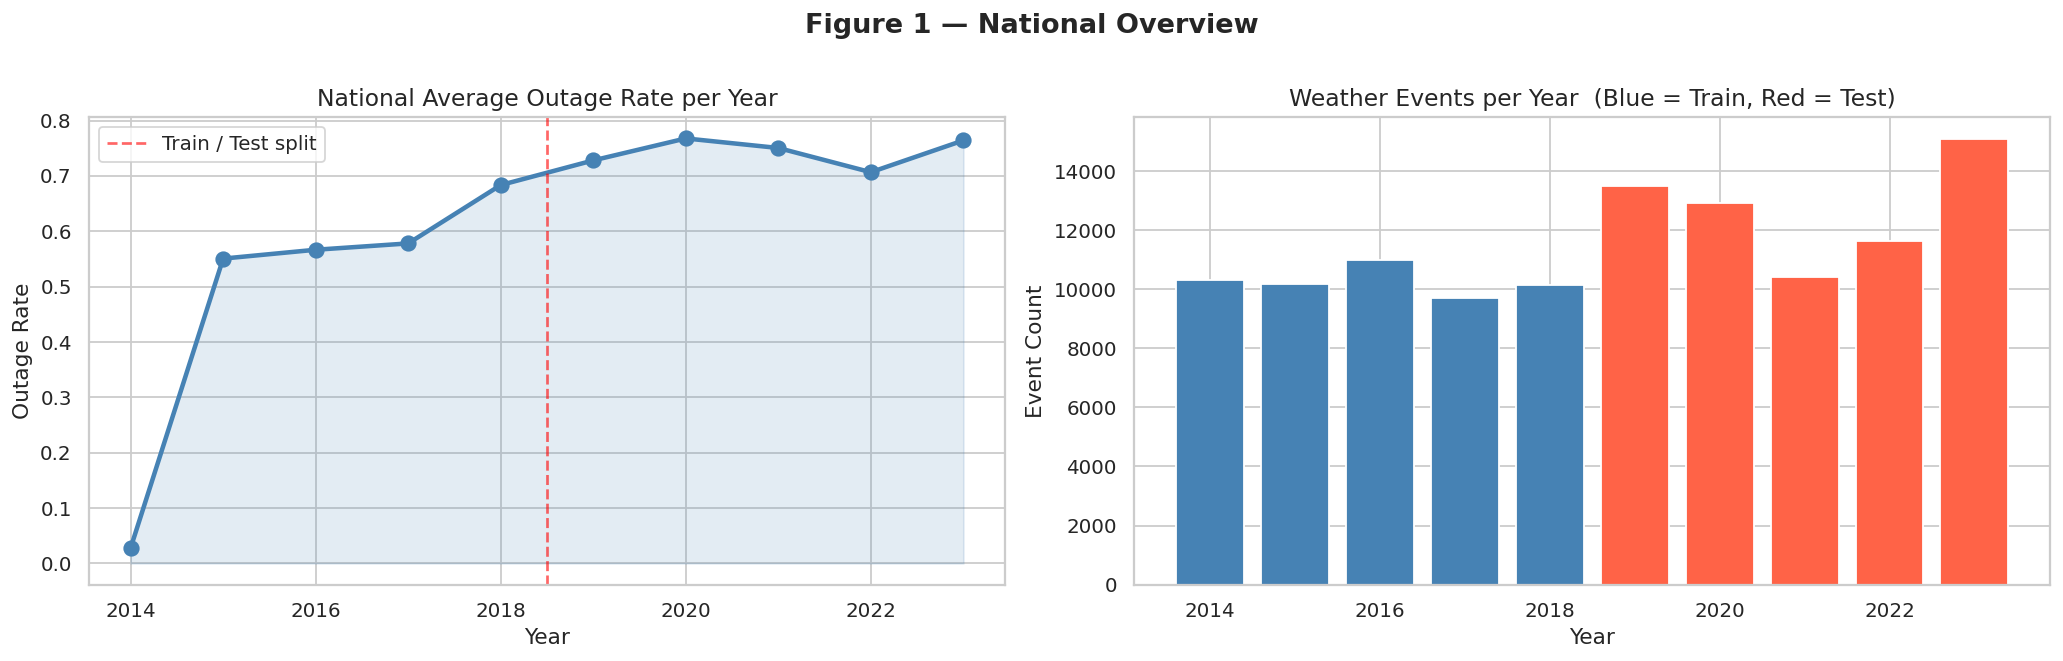

In [10]:
# ── Figure 1: National outage trend + event counts ───────────────────────────
nat_yr = df_f.groupby('year').agg(
    n_events=(TARGET_COL, 'count'), n_outages=(TARGET_COL, 'sum')
).reset_index()
nat_yr['outage_rate'] = nat_yr['n_outages'] / nat_yr['n_events']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(nat_yr['year'], nat_yr['outage_rate'], marker='o',
             color='steelblue', linewidth=2.5, markersize=8)
axes[0].axvline(2018.5, color='red', linestyle='--', alpha=0.6, label='Train / Test split')
axes[0].fill_between(nat_yr['year'], nat_yr['outage_rate'], alpha=0.15, color='steelblue')
axes[0].set_title('National Average Outage Rate per Year', fontsize=13)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Outage Rate')
axes[0].legend()

colors = ['steelblue' if y <= 2018 else 'tomato' for y in nat_yr['year']]
axes[1].bar(nat_yr['year'], nat_yr['n_events'], color=colors, edgecolor='white')
axes[1].set_title('Weather Events per Year  (Blue = Train, Red = Test)', fontsize=13)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Event Count')

plt.suptitle('Figure 1 — National Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig1_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()

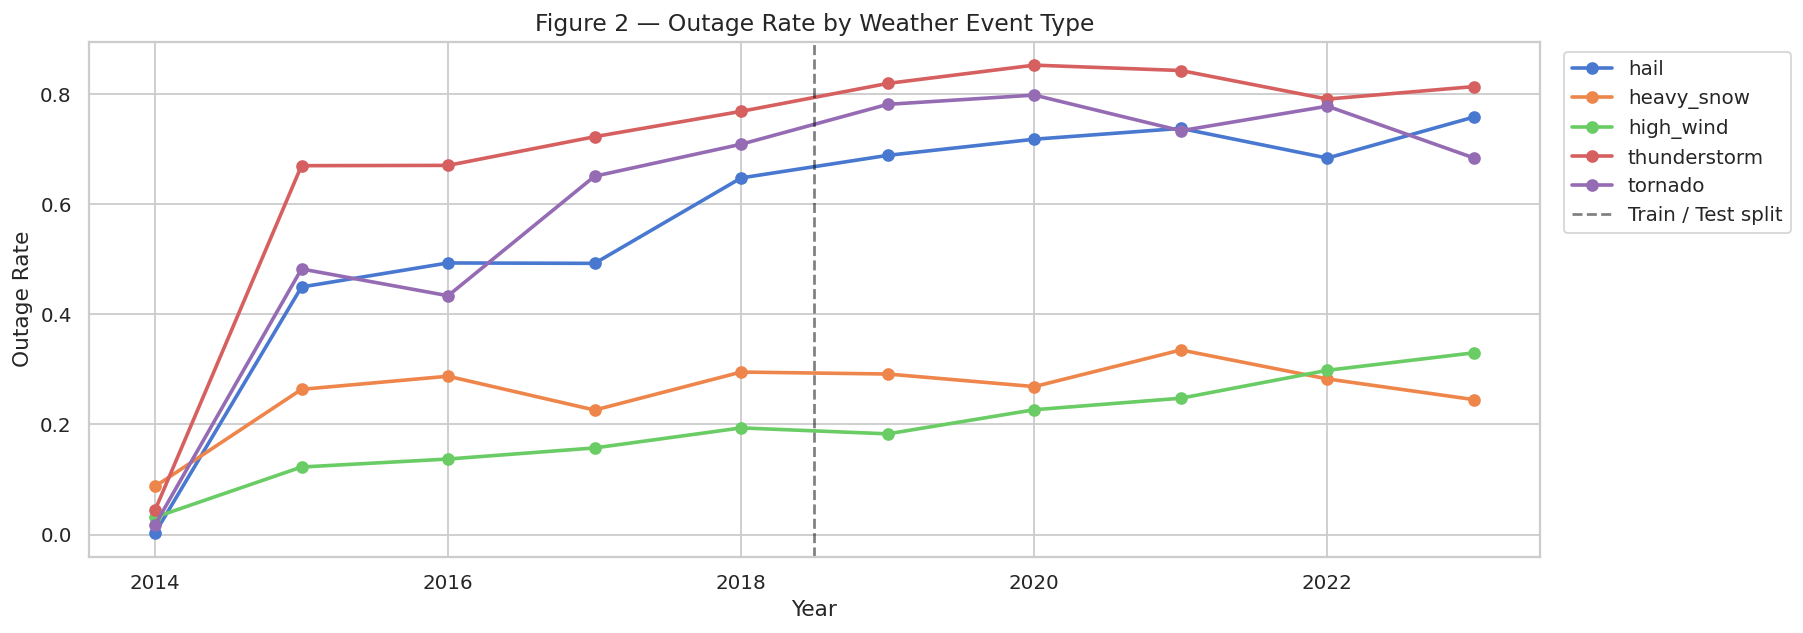

In [11]:
# ── Figure 2: Outage rate by weather event type ──────────────────────────────
et_yr = df_f.groupby([EVENT_COL, 'year']).agg(
    n_events=(TARGET_COL, 'count'), n_outages=(TARGET_COL, 'sum')
).reset_index()
et_yr['outage_rate'] = et_yr['n_outages'] / et_yr['n_events']

fig, ax = plt.subplots(figsize=(14, 5))
for etype, grp in et_yr.groupby(EVENT_COL):
    ax.plot(grp['year'], grp['outage_rate'], marker='o', label=etype, linewidth=2)
ax.axvline(2018.5, color='black', linestyle='--', alpha=0.5, label='Train / Test split')
ax.set_title('Figure 2 — Outage Rate by Weather Event Type', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Outage Rate')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/fig2_event_type_trend.png', dpi=150, bbox_inches='tight')
plt.show()

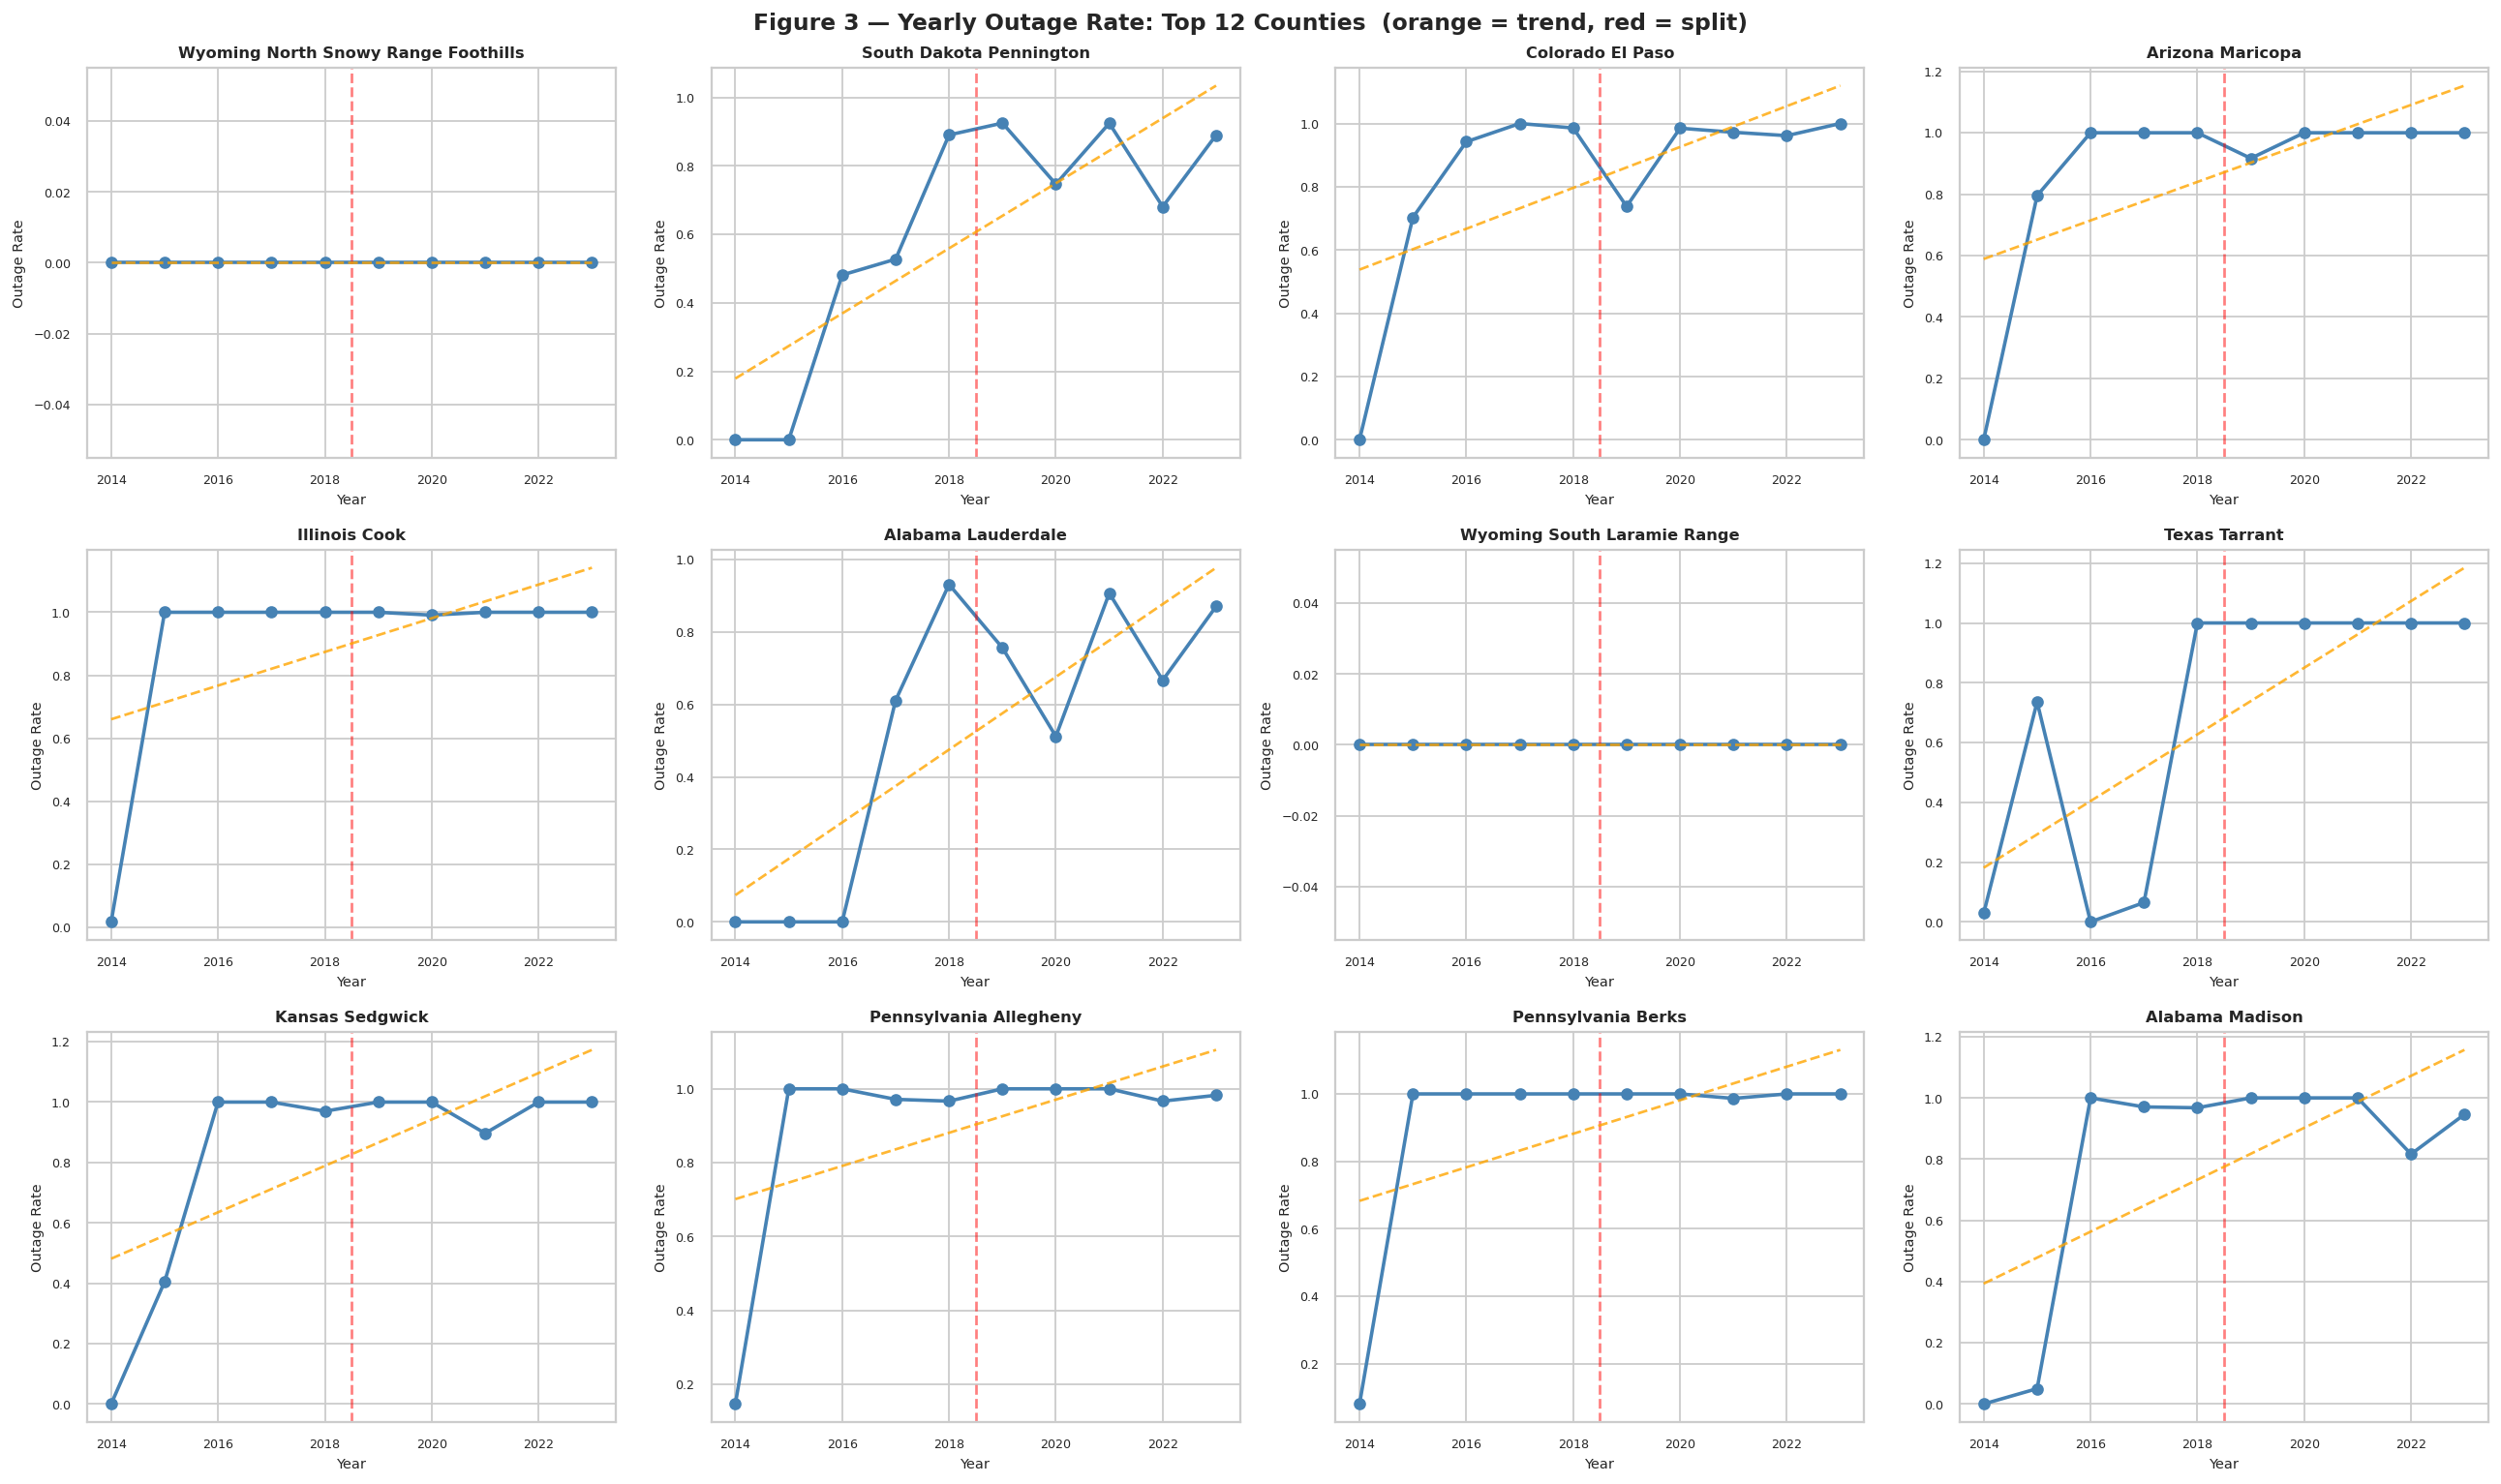

In [12]:
# ── Figure 3: Yearly outage rate for top-12 counties ─────────────────────────
top12 = county_counts.head(12)['county_id'].tolist()
top12_data = yr_agg[yr_agg['county_id'].isin(top12)]

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=False)
axes = axes.flatten()

for i, cid in enumerate(top12):
    sub = top12_data[top12_data['county_id'] == cid].sort_values('year')
    ax = axes[i]
    ax.plot(sub['year'], sub['outage_rate'], marker='o', color='steelblue', linewidth=2)
    ax.axvline(2018.5, color='red', linestyle='--', alpha=0.5)
    if len(sub) >= 4:
        z = np.polyfit(sub['year'], sub['outage_rate'], 1)
        ax.plot(sub['year'], np.poly1d(z)(sub['year']), '--', color='orange', alpha=0.8)
    ax.set_title(cid.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8); ax.set_ylabel('Outage Rate', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Figure 3 — Yearly Outage Rate: Top 12 Counties  (orange = trend, red = split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig3_top12_county_trends.png', dpi=150, bbox_inches='tight')
plt.show()

##  Part 2: Weather Normalization via Multi-Model Selection

**Core idea:** train candidate classifiers on 2014–2018 to learn the historical weather → outage relationship.  
Apply the best model to 2019–2023 to get a *predicted* outage probability for every event.  

The **residual** = `actual − predicted_proba` is our weather-normalized grid performance signal:

| Residual | Meaning |
|---|---|
| **Positive** | Actual > predicted — grid failed *more* than weather explains.  Infrastructure underperformed. |
| **Negative** | Actual < predicted — grid held up *better* than weather warranted.  Infrastructure outperformed. |
| **Near-zero** | Performed exactly as expected given weather conditions. |

**No temporal leakage:** `year` and `month` are excluded from features — they are temporal indices, not weather variables.

In [13]:
TRAIN_END  = 2018
TEST_START = 2019

df_train = df_f[df_f['year'] <= TRAIN_END].copy()
df_test  = df_f[df_f['year'] >= TEST_START].copy()

print(f'Train: {len(df_train):,} rows | years {sorted(df_train["year"].unique().astype(int))}')
print(f'Test : {len(df_test):,} rows  | years {sorted(df_test["year"].unique().astype(int))}')

Train: 51,373 rows | years [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Test : 63,556 rows  | years [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [14]:
# ── Label-encode county_id on df_f BEFORE building the feature list ──────────
_county_map = {c: i for i, c in enumerate(sorted(df_f['county_id'].unique()))}
df_f['county_id_encoded'] = df_f['county_id'].map(_county_map).fillna(-1).astype(int)
print(f'county_id_encoded: {df_f["county_id_encoded"].nunique()} unique values')

# ── Columns to exclude from features ─────────────────────────────────────────
DROP_COLS = [
    TARGET_COL, DATE_COL, STATE_COL, COUNTY_COL,
    'county_id', EVENT_COL, 'time',
    'event_latitude', 'event_longitude',
    'quarter', 'yearmonth',
    'year', 'month'           # <-- temporal leakage guard
]
DROP_COLS = [c for c in DROP_COLS if c in df_f.columns]

RAW_FEATURE_COLS = [
    c for c in df_f.columns
    if c not in DROP_COLS and df_f[c].dtype in [np.float64, np.int64, float, int]
]

print(f'Raw features ({len(RAW_FEATURE_COLS)}): {RAW_FEATURE_COLS}')
print('✅ year / month NOT in feature list:',
      'year' not in RAW_FEATURE_COLS and 'month' not in RAW_FEATURE_COLS)

county_id_encoded: 484 unique values
Raw features (26): ['temperature_2m', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 'winddirection_100m', 'windgusts_10m', 'surface_pressure', 'cloudcover', 'cloudcover_low', 'cloudcover_mid', 'cloudcover_high', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm', 'county_id_encoded']
✅ year / month NOT in feature list: True


In [15]:
# ── Feature Engineering ───────────────────────────────────────────────────────
def engineer_features(df):
    d = df.copy()

    # Thermal stress
    d['heat_index']     = d['temperature_2m'] + 0.33 * d['relative_humidity_2m'] - 4.0
    d['temp_extremity'] = np.abs(d['temperature_2m'] - 20.0)
    d['freeze_risk']    = np.where(d['temperature_2m'] <= 2.0, 2.0 - d['temperature_2m'], 0.0)

    # Wind stress
    sustained             = d['windspeed_10m'].replace(0, 0.1)
    d['wind_power_density'] = d['windspeed_10m'] ** 3
    d['gust_ratio']       = d['windgusts_10m'] / sustained
    d['wind_gust_stress'] = d['windgusts_10m'] * d['gust_ratio']
    d['wind_shear']       = np.abs(d['windspeed_100m'] - d['windspeed_10m'])

    # Precipitation / moisture
    d['total_precip']    = d['precipitation'].fillna(0)
    d['ice_load_risk']   = d['rain'].fillna(0) * np.where(d['temperature_2m'] <= 2.0, 1.0, 0.0)
    d['snow_weight']     = d['snowfall'].fillna(0) * (1.0 / (np.abs(d['temperature_2m']) + 1.0))
    d['snow_depth_load'] = d['snow_depth'].fillna(0)

    # Interaction terms
    d['wind_rain_compound']      = d['windgusts_10m'] * d['total_precip']
    d['windspeed_rain_product']  = d['windspeed_10m'] * d['total_precip']
    d['gust_rain_interaction']   = d['gust_ratio']    * d['total_precip']
    d['wind_freeze_interaction'] = d['windspeed_10m'] * d['freeze_risk']
    d['gust_freeze_interaction'] = d['windgusts_10m'] * d['freeze_risk']
    d['rain_humidity_interaction']= d['total_precip'] * d['relative_humidity_2m'] / 100.0

    # Threshold / indicator features
    d['is_high_wind']       = (d['windgusts_10m']  >= 20.0).astype(int)
    d['is_freezing']        = (d['temperature_2m'] <=  0.0).astype(int)
    d['is_near_freeze']     = (d['temperature_2m'] <=  2.0).astype(int)
    d['is_heavy_precip']    = (d['total_precip']   >=  0.25).astype(int)
    d['is_extreme_heat']    = (d['temperature_2m'] >= 35.0).astype(int)
    d['is_high_gust_ratio'] = (d['gust_ratio']     >=  2.0).astype(int)
    d['is_wind_and_precip'] = ((d['windgusts_10m'] >= 15.0) & (d['total_precip'] >= 0.05)).astype(int)
    d['is_wind_and_freeze'] = ((d['windgusts_10m'] >= 10.0) & (d['temperature_2m'] <= 2.0)).astype(int)
    d['is_extreme_compound']= (d['is_high_wind'] & d['is_heavy_precip']).astype(int)

    # Compound hazard proxies
    d['winter_storm_index'] = (
        d['freeze_risk'] * (1 + d['windspeed_10m'] / 20.0) * (1 + d['snowfall'].fillna(0))
    )
    d['multi_hazard_index'] = (
        d['wind_power_density'] / 1000.0 + d['total_precip'] * 10.0
        + d['freeze_risk'] * 5.0 + d['snow_depth_load']
    )

    # Atmospheric instability
    d['dewpoint_depression']   = d['temperature_2m'] - d['dew_point_2m']
    d['convective_cloud_risk'] = d['cloudcover_low'] * (1.0 / (d['dewpoint_depression'].abs() + 1.0))

    # Soil / ground conditions
    d['shallow_soil_saturation'] = (d['soil_moisture_0_to_7cm'] + d['soil_moisture_7_to_28cm']) / 2.0
    d['soil_temp_gradient']      = np.abs(d['soil_temperature_0_to_7cm'] - d['soil_temperature_28_to_100cm'])
    d['pressure_anomaly']        = np.abs(d['surface_pressure'] - 1013.25)

    return d

ENGINEERED_COLS = [
    'heat_index', 'temp_extremity', 'freeze_risk',
    'wind_power_density', 'gust_ratio', 'wind_gust_stress', 'wind_shear',
    'total_precip', 'ice_load_risk', 'snow_weight', 'snow_depth_load',
    'wind_rain_compound', 'windspeed_rain_product', 'gust_rain_interaction',
    'wind_freeze_interaction', 'gust_freeze_interaction', 'rain_humidity_interaction',
    'is_high_wind', 'is_freezing', 'is_near_freeze', 'is_heavy_precip',
    'is_extreme_heat', 'is_high_gust_ratio',
    'is_wind_and_precip', 'is_wind_and_freeze', 'is_extreme_compound',
    'winter_storm_index', 'multi_hazard_index',
    'dewpoint_depression', 'convective_cloud_risk',
    'shallow_soil_saturation', 'soil_temp_gradient', 'pressure_anomaly',
]

df_f_eng = engineer_features(df_f)
FEATURE_COLS = RAW_FEATURE_COLS + ENGINEERED_COLS

print(f'Total features: {len(FEATURE_COLS)}')
print(f'  Raw        : {len(RAW_FEATURE_COLS)}  (includes county_id_encoded)')
print(f'  Engineered : {len(ENGINEERED_COLS)}')

Total features: 59
  Raw        : 26  (includes county_id_encoded)
  Engineered : 33


In [16]:
# ── Multi-Model Training & Selection ─────────────────────────────────────────
df_train_eng = df_f_eng[df_f_eng['year'] <= 2018].copy()
df_test_eng  = df_f_eng[df_f_eng['year'] >= 2019].copy()

X_train = df_train_eng[FEATURE_COLS].fillna(0)
y_train = df_train_eng[TARGET_COL]
X_test  = df_test_eng[FEATURE_COLS].fillna(0)
y_test  = df_test_eng[TARGET_COL]

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1, class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', use_label_encoder=False,
        random_state=42, n_jobs=-1, verbosity=0),
}

results, trained_models = {}, {}
print('--- Individual Model Performance ---')
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    y_pred  = model.predict(X_test_sc)
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    results[name] = dict(
        AUC_ROC=round(auc, 4), Accuracy=round(acc, 4), F1_macro=round(f1, 4),
        TrainTime=round(elapsed, 1), y_proba=y_proba, y_pred=y_pred)
    trained_models[name] = model
    print(f'{name}: AUC = {auc:.4f} | Acc = {acc:.4f} | F1 = {f1:.4f} | {elapsed:.1f}s')

best_name  = max(results, key=lambda n: results[n]['AUC_ROC'])
best_model = trained_models[best_name]
y_proba    = results[best_name]['y_proba']
y_pred     = results[best_name]['y_pred']

print(f'\n🏆 Best model: {best_name}  (AUC = {results[best_name]["AUC_ROC"]})')

--- Individual Model Performance ---
Logistic Regression: AUC = 0.6958 | Acc = 0.6741 | F1 = 0.6254 | 1.9s
Random Forest: AUC = 0.7431 | Acc = 0.6811 | F1 = 0.6435 | 21.2s
XGBoost: AUC = 0.7938 | Acc = 0.7093 | F1 = 0.6740 | 3.7s

🏆 Best model: XGBoost  (AUC = 0.7938)


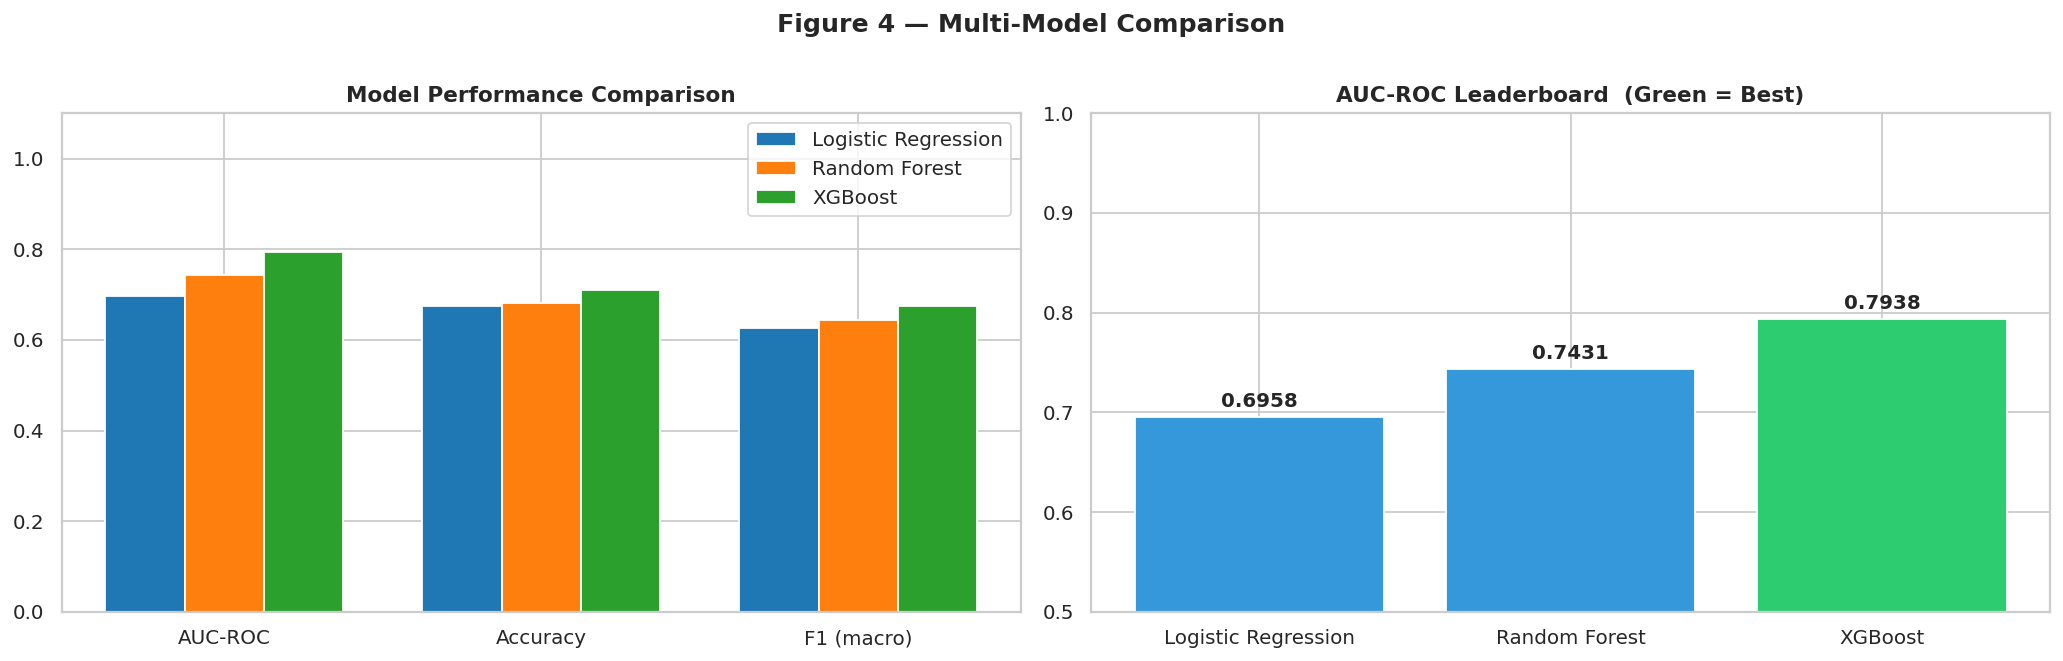

In [17]:
# ── Figure 4: Model Comparison ───────────────────────────────────────────────
model_names = list(results.keys())
palette     = plt.cm.tab10.colors
fig, axes   = plt.subplots(1, 2, figsize=(16, 5))

metric_names = ['AUC_ROC', 'Accuracy', 'F1_macro']
x = np.arange(len(metric_names)); width = 0.25

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_names]
    axes[0].bar(x + (i-1)*width, vals, width, label=name, color=palette[i], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(['AUC-ROC', 'Accuracy', 'F1 (macro)'])
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0].legend()

auc_vals    = [results[n]['AUC_ROC'] for n in model_names]
bar_colors  = ['#2ecc71' if n == best_name else '#3498db' for n in model_names]
axes[1].bar(model_names, auc_vals, color=bar_colors, edgecolor='white')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC-ROC Leaderboard  (Green = Best)', fontsize=12, fontweight='bold')
for i, v in enumerate(auc_vals):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Figure 4 — Multi-Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

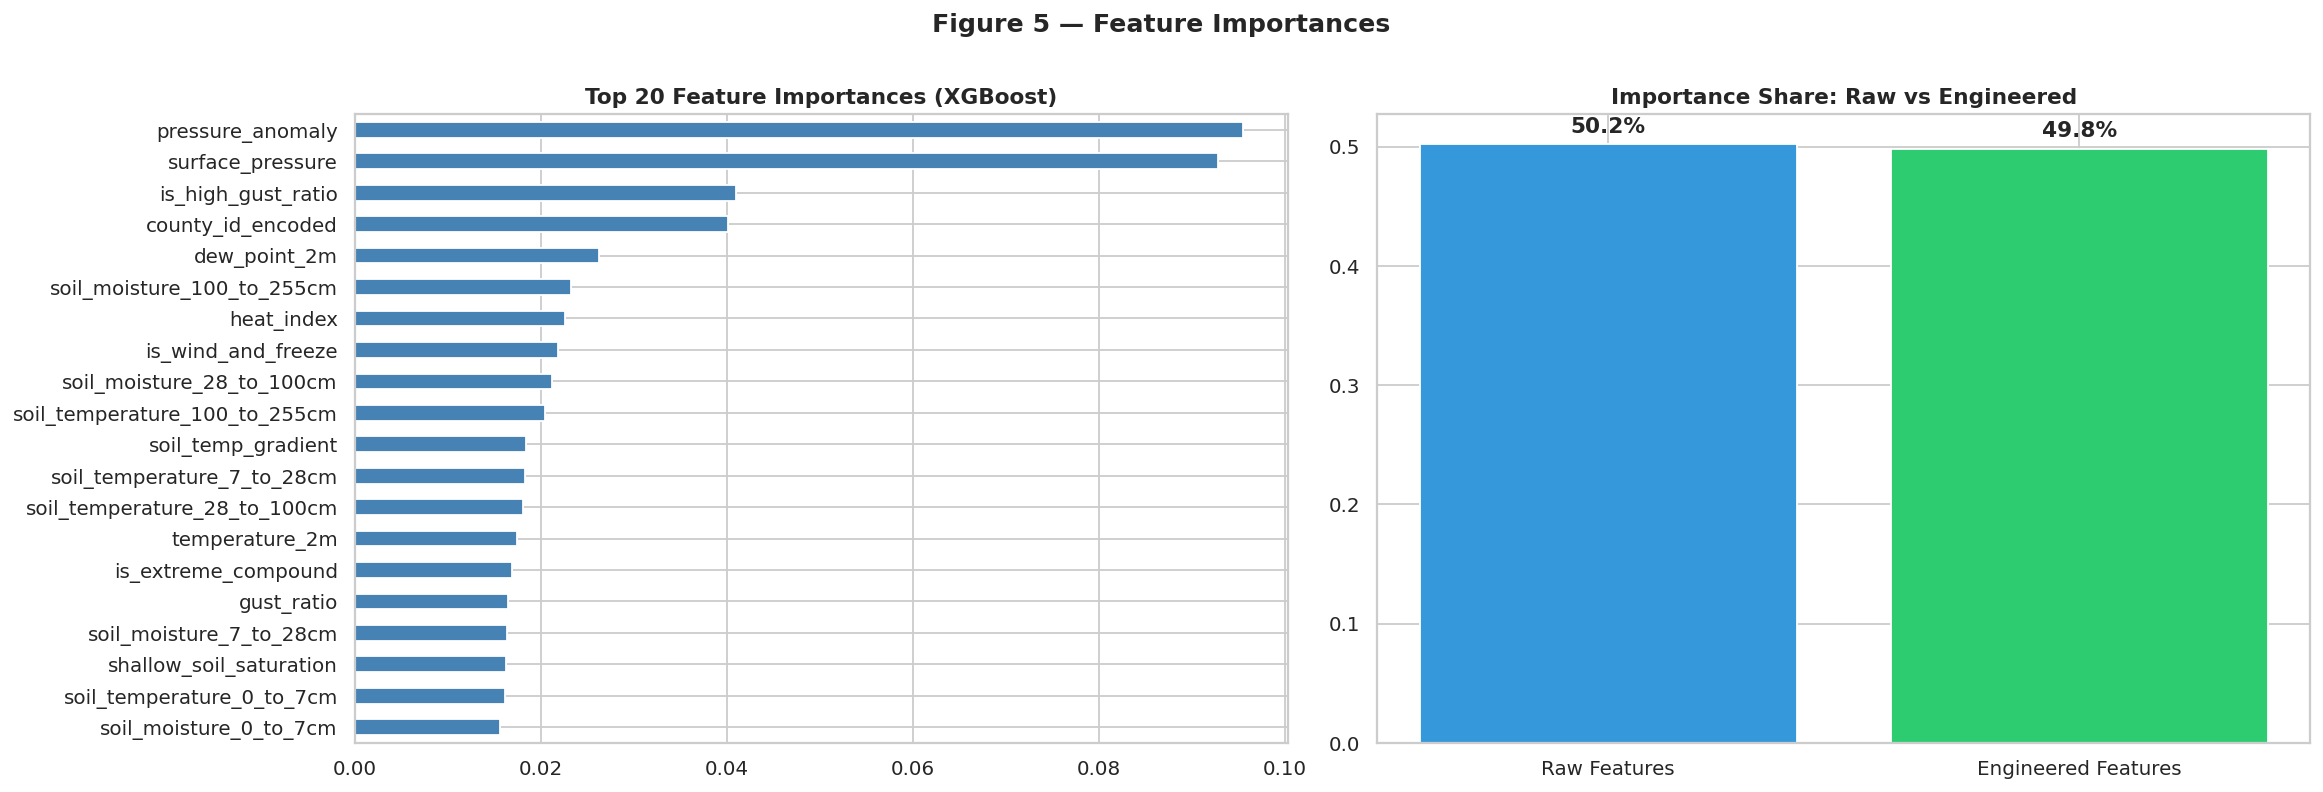

In [18]:
# ── Figure 5: Feature Importance ─────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    imp_title   = f'Top 20 Feature Importances ({best_name})'
else:
    importances = np.abs(best_model.coef_[0])
    imp_title   = f'Top 20 Feature Coefficients ({best_name})'

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
raw_imp  = feat_imp[feat_imp.index.isin(RAW_FEATURE_COLS)].sum()
eng_imp  = feat_imp[feat_imp.index.isin(ENGINEERED_COLS)].sum()
total    = raw_imp + eng_imp

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
feat_imp.head(20).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title(imp_title, fontsize=12, fontweight='bold')

axes[1].bar(['Raw Features', 'Engineered Features'], [raw_imp, eng_imp],
            color=['#3498db', '#2ecc71'], edgecolor='white')
axes[1].set_title('Importance Share: Raw vs Engineered', fontsize=12, fontweight='bold')
for i, v in enumerate([raw_imp, eng_imp]):
    axes[1].text(i, v + total*0.01, f'{v/total:.1%}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Figure 5 — Feature Importances', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Residual stats:
count    63556.0000
mean         0.2086
std          0.3926
min         -0.9891
25%         -0.0035
50%          0.2299
75%          0.4663
max          0.9950
Name: residual, dtype: float64


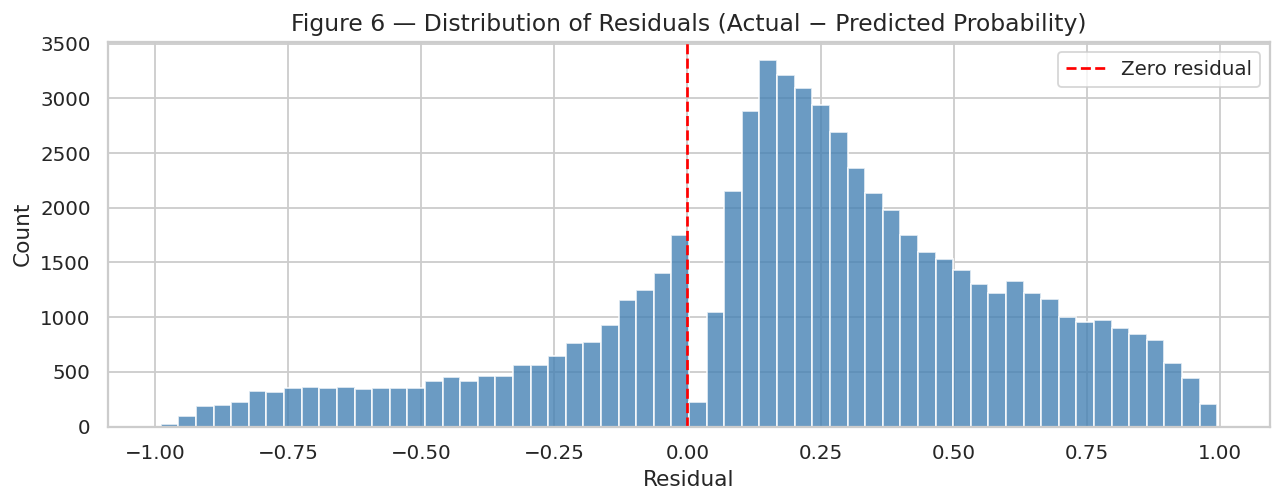

In [19]:
# ── Residual computation ──────────────────────────────────────────────────────
df_test = df_test_eng.copy()
df_test['pred_proba']  = y_proba
df_test['pred_binary'] = y_pred
df_test['residual']    = df_test[TARGET_COL] - df_test['pred_proba']

print('Residual stats:')
print(df_test['residual'].describe().round(4))

# ── Figure 6: Residual distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_test['residual'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
ax.set_title('Figure 6 — Distribution of Residuals (Actual − Predicted Probability)', fontsize=13)
ax.set_xlabel('Residual'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig6_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Class balance filter ─────────────────────────────────────────────────────
county_test_class_counts = (
    df_test.groupby(['county_id', TARGET_COL]).size()
    .unstack(fill_value=0)
    .rename(columns={0: 'n_no_outage', 1: 'n_outage'})
)
county_test_class_counts['min_class'] = county_test_class_counts[['n_no_outage','n_outage']].min(axis=1)
valid_resid_counties = county_test_class_counts[
    county_test_class_counts['min_class'] >= MIN_TEST_EACH
].index.tolist()

n_test_counties = county_test_class_counts.shape[0]
log_attrition('Step 3: MIN_TEST_EACH (class balance)', n_test_counties, len(valid_resid_counties),
              f'Both classes need >= {MIN_TEST_EACH} test-set instances')

print(f'Counties in test set         : {n_test_counties:,}')
print(f'  Passing MIN_TEST_EACH={MIN_TEST_EACH}  : {len(valid_resid_counties):,}')
print(f'  Excluded (imbalanced)      : {n_test_counties - len(valid_resid_counties):,}')

# Per-county per-year residual aggregation
resid_yr = (
    df_test[df_test['county_id'].isin(valid_resid_counties)]
    .groupby(['county_id', 'year'])
    .agg(n_events=(TARGET_COL, 'count'),
         actual_rate=(TARGET_COL, 'mean'),
         mean_pred_prob=('pred_proba', 'mean'),
         mean_residual=('residual', 'mean'))
    .reset_index()
)
resid_yr = resid_yr[resid_yr['n_events'] >= 5].copy()
print(f'\nCounty-year residual records : {len(resid_yr):,}')
resid_yr.head(5)

Counties in test set         : 484
  Passing MIN_TEST_EACH=20  : 148
  Excluded (imbalanced)      : 336

County-year residual records : 731


,county_id,year,n_events,actual_rate,mean_pred_prob,mean_residual
0,alabama_clarke,2019,9,0.555556,0.296216,0.259339
1,alabama_clarke,2020,27,0.629630,0.213089,0.416540
2,alabama_clarke,2021,26,0.730769,0.226724,0.504045
3,alabama_clarke,2022,25,0.720000,0.154047,0.565953
4,alabama_clarke,2023,32,0.593750,0.254724,0.339026


##  Part 3: Time Series Analysis

Three layers building on each other.  Layer 3 is the **primary signal** for county ranking;  
Layers 1–2 provide interpretive context.

---
### Layer 1: Linear Trend per County (Raw Outage Rate)

Fit `OutageRate_t = β₀ + β₁ × Year_t + ε_t` on each county's full 2014–2023 series.  
- `slope (β₁)` → direction of change  
- `p-value` → statistical confidence

In [21]:
trend_results = []

for cid, grp in yr_agg.groupby('county_id'):
    grp = grp.sort_values('year')
    if len(grp) < 5:
        continue
    x = grp['year'].values.astype(float)
    y = grp['outage_rate'].values
    slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
    early = grp[grp['year'] <= 2018]['outage_rate'].mean()
    late  = grp[grp['year'] >= 2019]['outage_rate'].mean()
    trend_results.append({
        'county_id' : cid,
        'state'     : cid.split('_')[0],
        'n_years'   : len(grp),
        'slope'     : round(slope, 5),
        'p_value'   : round(p_val, 4),
        'r_squared' : round(r_val**2, 4),
        'early_rate': round(early, 4) if not np.isnan(early) else np.nan,
        'late_rate' : round(late, 4)  if not np.isnan(late)  else np.nan,
        'delta_rate': round(late - early, 4) if not (np.isnan(early) or np.isnan(late)) else np.nan,
        'significant': p_val < 0.05,
    })

trend_df = pd.DataFrame(trend_results)
BUFFER = 0.005
trend_df['trend_label'] = trend_df['slope'].apply(
    lambda s: 'Improving' if s < -BUFFER else ('Deteriorating' if s > BUFFER else 'Stable'))
trend_df['Conclusion'] = trend_df['trend_label']

n_l1_in = yr_agg['county_id'].nunique()
log_attrition('Step 4: Layer 1 — min 5 years', n_l1_in, len(trend_df),
              'Linear regression requires >= 5 annual data points')

print(f'Counties analysed: {len(trend_df):,}')
print('\nTrend distribution:'); print(trend_df['trend_label'].value_counts())
print(f'\nSignificant trends (p<0.05): {trend_df["significant"].sum()}')

display_cols = ['county_id', 'slope', 'p_value', 'significant', 'Conclusion']
print('\n' + '='*80)
print('TOP 5 MOST IMPROVING COUNTIES (Layer 1 — Raw Trend)')
print('='*80)
print(trend_df.nsmallest(5, 'slope')[display_cols].to_string(index=False))
print('\n' + '='*80)
print('TOP 5 MOST DETERIORATING COUNTIES (Layer 1 — Raw Trend)')
print('='*80)
print(trend_df.nlargest(5, 'slope')[display_cols].to_string(index=False))

Counties analysed: 484

Trend distribution:
trend_label
Deteriorating    445
Stable            33
Improving          6
Name: count, dtype: int64

Significant trends (p<0.05): 157

TOP 5 MOST IMPROVING COUNTIES (Layer 1 — Raw Trend)
            county_id    slope  p_value  significant Conclusion
pennsylvania_lawrence -0.03374   0.1739        False  Improving
     wisconsin_sawyer -0.02740   0.4232        False  Improving
    arkansas_lawrence -0.02047   0.5398        False  Improving
      florida_wakulla -0.01633   0.4481        False  Improving
      delaware_sussex -0.00812   0.0858        False  Improving

TOP 5 MOST DETERIORATING COUNTIES (Layer 1 — Raw Trend)
         county_id   slope  p_value  significant    Conclusion
 alabama_jefferson 0.14545   0.0017         True Deteriorating
        texas_bell 0.14545   0.0017         True Deteriorating
    alabama_mobile 0.14182   0.0011         True Deteriorating
    utah_salt lake 0.13750   0.0023         True Deteriorating
tennessee_la

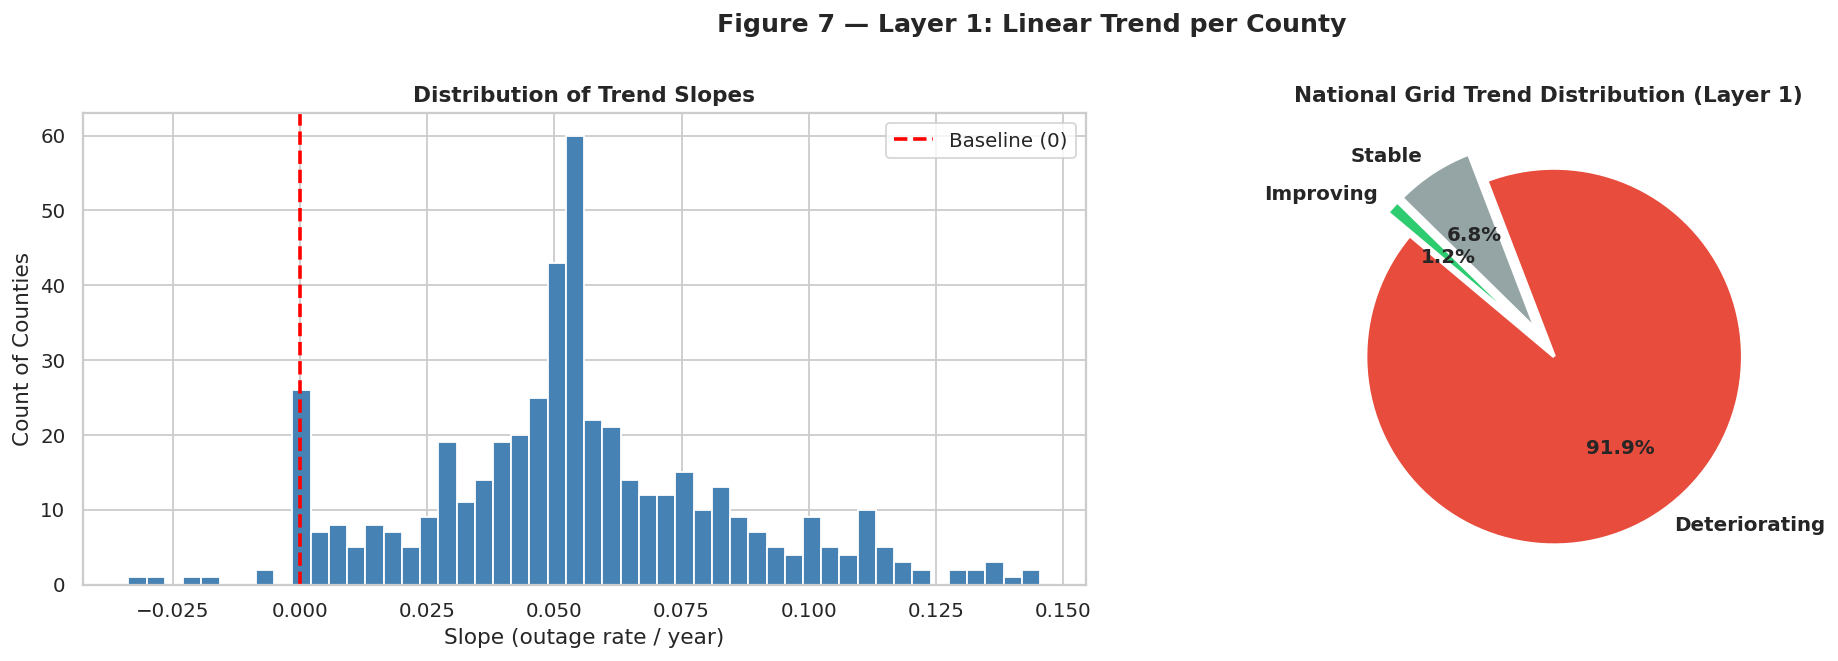

In [22]:
# ── Figure 7: Slope distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(trend_df['slope'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Baseline (0)')
axes[0].set_title('Distribution of Trend Slopes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Slope (outage rate / year)'); axes[0].set_ylabel('Count of Counties')
axes[0].legend()

# Pie chart
colors_map = {'Improving': '#2ecc71', 'Stable': '#95a5a6', 'Deteriorating': '#e74c3c'}
counts = trend_df['Conclusion'].value_counts()
colors = [colors_map.get(l) for l in counts.index]
explode = [0.05 if l == 'Deteriorating' else 0.12 for l in counts.index]
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
            colors=colors, explode=explode,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('National Grid Trend Distribution (Layer 1)', fontsize=12, fontweight='bold')

plt.suptitle('Figure 7 — Layer 1: Linear Trend per County', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig7_layer1_trend.png', dpi=150, bbox_inches='tight')
plt.show()

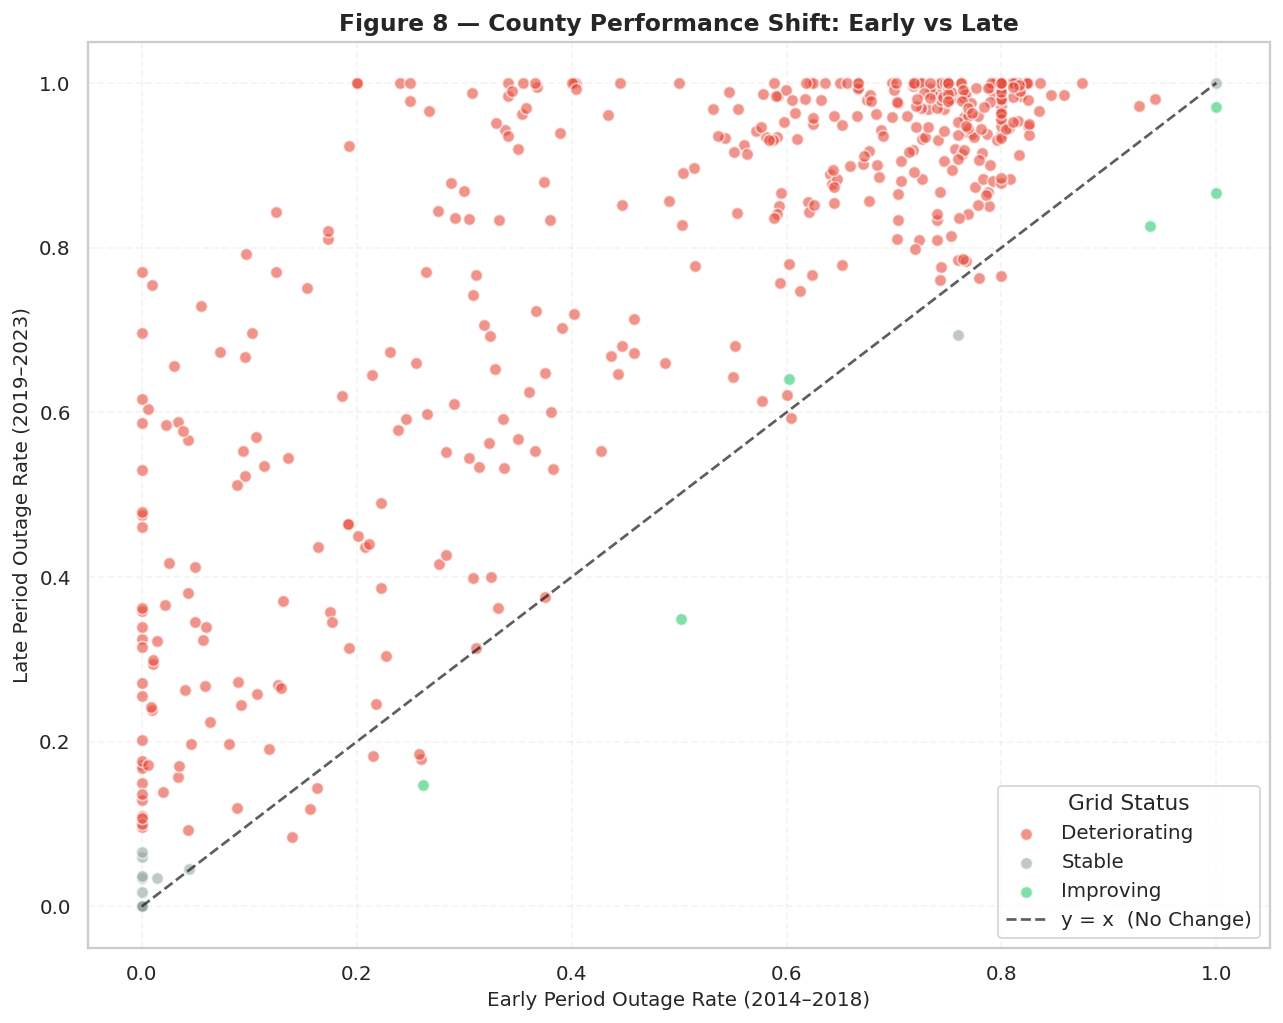

Points ABOVE the diagonal → outage rate increased.
Points BELOW the diagonal → outage rate decreased.
But again — is this weather or the grid?  Layer 3 answers this.


In [23]:
# ── Figure 8: Early vs Late scatter ──────────────────────────────────────────
plot_df = trend_df.dropna(subset=['early_rate', 'late_rate'])

fig, ax = plt.subplots(figsize=(10, 8))
for label in ['Deteriorating', 'Stable', 'Improving']:
    grp = plot_df[plot_df['Conclusion'] == label]
    ax.scatter(grp['early_rate'], grp['late_rate'],
               c=colors_map[label], label=label, alpha=0.6, s=45, edgecolor='white')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.7, label='y = x  (No Change)')
ax.set_xlabel('Early Period Outage Rate (2014–2018)', fontsize=11)
ax.set_ylabel('Late Period Outage Rate (2019–2023)', fontsize=11)
ax.set_title('Figure 8 — County Performance Shift: Early vs Late', fontsize=13, fontweight='bold')
ax.legend(title='Grid Status', frameon=True)
ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('/content/fig8_early_vs_late.png', dpi=150, bbox_inches='tight')
plt.show()

print('Points ABOVE the diagonal → outage rate increased.')
print('Points BELOW the diagonal → outage rate decreased.')
print('But again — is this weather or the grid?  Layer 3 answers this.')

---
### Layer 3: Weather-Normalized Residual Trends

> Layer 2 (seasonal decomposition) is available as an optional extension; its per-county plots are voluminous  
> and not required for the final ranking, so it is omitted from this production notebook.

Instead of looking at raw outage rates, we look at the residuals from our trained model —  
aggregated per county per year across 2019–2023.

We fit:  `Residual_t = α₀ + α₁(Year_t) + ε_t`  per county and compute:
- `mean_residual` — average of (actual − predicted) across all test-period events
- `resid_slope` — linear trend in that mean residual over 2019–2023

**Classification logic:**

| Condition | Label |
|---|---|
| `mean_residual < macro_mean − 0.10` AND `resid_slope < 0` | ✅ Genuinely Improved |
| `mean_residual > macro_mean + 0.10` AND `resid_slope > 0` | ❌ Genuinely Deteriorated |
| Everything else | ⚪ Mixed / Stable |

In [24]:
resid_trend = []

for cid, grp in resid_yr.groupby('county_id'):
    grp = grp.sort_values('year')
    if len(grp) < 3:
        continue
    x = grp['year'].values.astype(float)
    y = grp['mean_residual'].values
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    resid_trend.append({
        'county_id'    : cid,
        'state'        : cid.split('_')[0],
        'mean_residual': round(grp['mean_residual'].mean(), 4),
        'resid_slope'  : round(slope, 5),
        'resid_p_value': round(p_val, 4),
        'n_years'      : len(grp),
    })

resid_trend_df = pd.DataFrame(resid_trend)
macro_mean     = resid_trend_df['mean_residual'].mean()
DELTA          = 0.10

resid_trend_df['grid_status'] = resid_trend_df.apply(
    lambda r:
        'Genuinely Improved'     if (r['mean_residual'] < macro_mean - DELTA and r['resid_slope'] < 0)
        else ('Genuinely Deteriorated' if (r['mean_residual'] > macro_mean + DELTA and r['resid_slope'] > 0)
              else 'Mixed/Stable'),
    axis=1
)

log_attrition('Step 5: Layer 3 — min 3 test years', len(valid_resid_counties), len(resid_trend_df),
              'Residual regression requires >= 3 annual data points')

print(f'Counties in Layer 3 : {len(resid_trend_df):,}')
print(f'Macro mean residual : {macro_mean:.4f}')
print('\nGrid status distribution:')
print(resid_trend_df['grid_status'].value_counts())

Counties in Layer 3 : 148
Macro mean residual : 0.1353

Grid status distribution:
grid_status
Mixed/Stable              100
Genuinely Improved         27
Genuinely Deteriorated     21
Name: count, dtype: int64


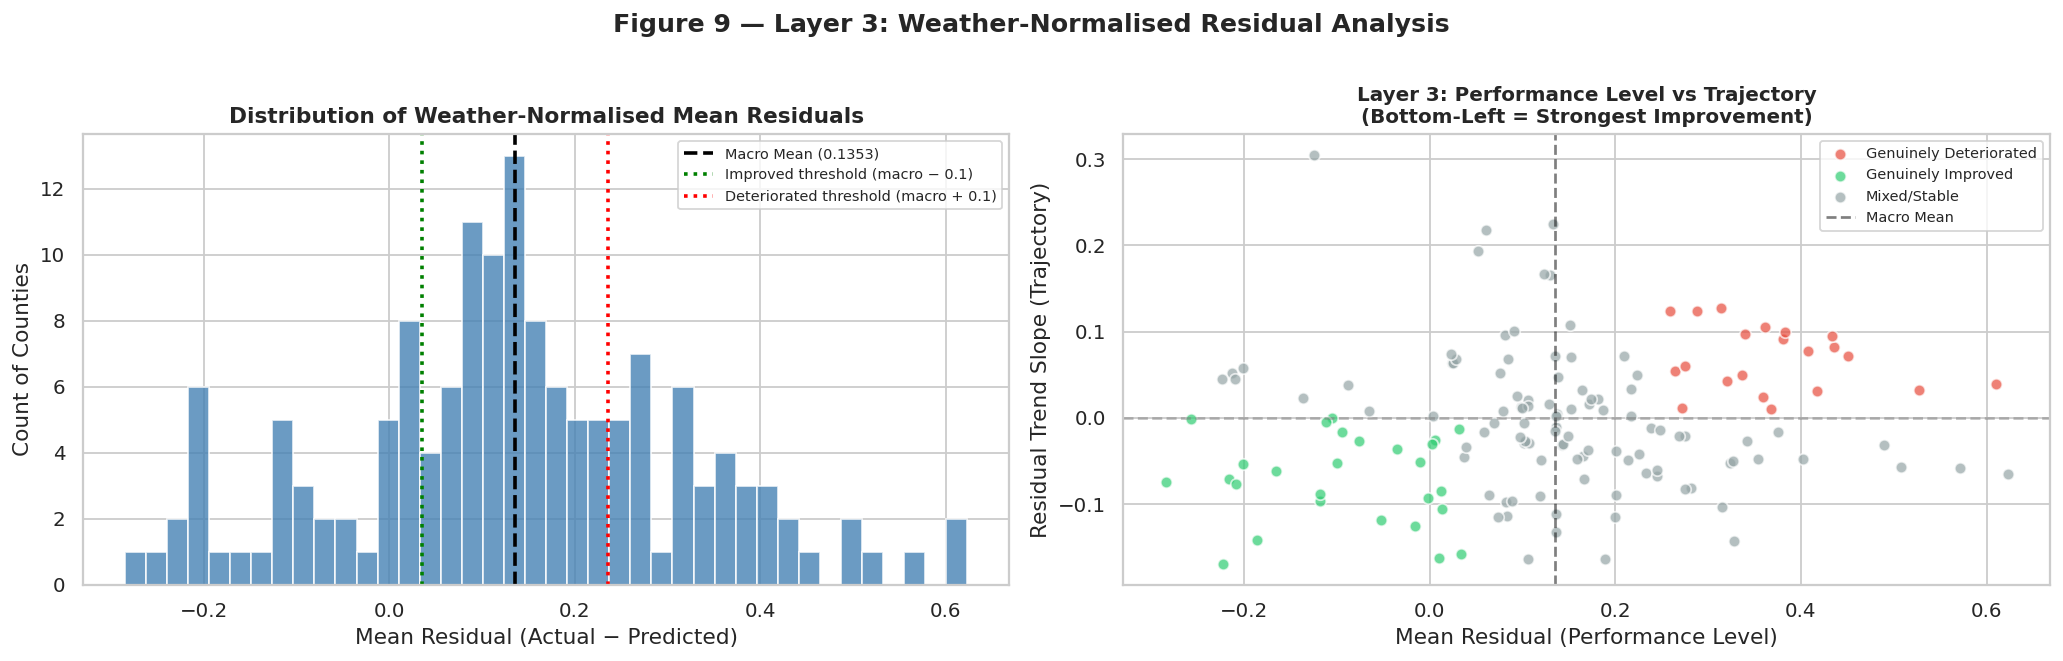

In [25]:
# ── Figure 9: Weather-normalized residual distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(resid_trend_df['mean_residual'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(macro_mean,          color='black', linestyle='--', linewidth=2, label=f'Macro Mean ({macro_mean:.4f})')
axes[0].axvline(macro_mean - DELTA,  color='green', linestyle=':', linewidth=2, label=f'Improved threshold (macro − {DELTA})')
axes[0].axvline(macro_mean + DELTA,  color='red',   linestyle=':', linewidth=2, label=f'Deteriorated threshold (macro + {DELTA})')
axes[0].set_title('Distribution of Weather-Normalised Mean Residuals', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Residual (Actual − Predicted)'); axes[0].set_ylabel('Count of Counties')
axes[0].legend(fontsize=8)

# Scatter: performance level vs trajectory
status_colors = {'Genuinely Deteriorated': '#e74c3c', 'Genuinely Improved': '#2ecc71', 'Mixed/Stable': '#95a5a6'}
for status, grp in resid_trend_df.groupby('grid_status'):
    axes[1].scatter(grp['mean_residual'], grp['resid_slope'],
                    c=status_colors[status], label=status, alpha=0.7, s=40, edgecolor='white')
axes[1].axvline(macro_mean, color='black', linestyle='--', alpha=0.5, label='Macro Mean')
axes[1].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Mean Residual (Performance Level)')
axes[1].set_ylabel('Residual Trend Slope (Trajectory)')
axes[1].set_title('Layer 3: Performance Level vs Trajectory\n(Bottom-Left = Strongest Improvement)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Figure 9 — Layer 3: Weather-Normalised Residual Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig9_layer3_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

##  Part 4: Final County Rankings

### Scoring Formula

**Step 1 — Normalise** each metric to [−1, 1] relative to the macro mean:

```
mean_resid_norm  = clip(−(mean_residual − macro_mean) / P95(|mean_residual|), −1, 1)
resid_slope_norm = clip(−resid_slope / P95(|resid_slope|), −1, 1)
```

**Step 2 — Raw Score** (higher = grid performing better relative to weather):

```
raw_score = 0.30 × mean_resid_norm + 0.70 × resid_slope_norm
```

**Step 3 — Map to 0–100:**

```
layer3_score = 50 + 50 × raw_score
```

**Final status thresholds:**

| Score | Label |
|---|---|
| ≥ 75 | ✅ Confidently Improved |
| ≥ 60 | 🟢 Likely Improved |
| ≤ 25 | ❌ Confidently Deteriorated |
| ≤ 40 | 🔴 Likely Deteriorated |
| else | ⚪ Stable / Inconclusive |

In [26]:
# ── Attrition funnel ──────────────────────────────────────────────────────────
# Merge Layer 1 and Layer 3 outputs; zero-rate county filter
final_df = resid_trend_df.merge(
    trend_df[['county_id','slope','p_value','early_rate','late_rate','delta_rate','significant','trend_label']],
    on='county_id', how='inner')

# Drop counties with early_rate == 0 (model calibration artefacts, not genuine improvement)
n_before_zero = len(final_df)
final_df = final_df[final_df['early_rate'] > 0].copy()
log_attrition('Step 6: Zero early-rate filter', n_before_zero, len(final_df),
              'early_rate == 0 → artefact negative residuals')

print(f'Counties after merge + zero-rate filter: {len(final_df):,}')

# ── Scoring ───────────────────────────────────────────────────────────────────
p95_resid = np.percentile(np.abs(final_df['mean_residual'] - macro_mean), 95)
p95_slope = np.percentile(np.abs(final_df['resid_slope']), 95)

def safe_norm(val, ref):
    return float(np.clip(val / ref, -1, 1)) if ref > 0 else 0.0

final_df['mean_resid_norm']  = final_df['mean_residual'].apply(
    lambda v: safe_norm(-(v - macro_mean), p95_resid))
final_df['resid_slope_norm'] = final_df['resid_slope'].apply(
    lambda v: safe_norm(-v, p95_slope))

final_df['raw_score']    = 0.30 * final_df['mean_resid_norm'] + 0.70 * final_df['resid_slope_norm']
final_df['layer3_score'] = (50 + 50 * final_df['raw_score']).clip(0, 100)
final_df['Score']        = final_df['layer3_score'].round(2)

def assign_status(s, resid_p):
    if s >= 75 and resid_p < 0.05: return 'Confidently Improved'
    if s >= 60: return 'Likely Improved'
    if s <= 25 and resid_p < 0.05: return 'Confidently Deteriorated'
    if s <= 40: return 'Likely Deteriorated'
    return 'Stable / Inconclusive'

final_df['final_status'] = final_df.apply(
    lambda r: assign_status(r['Score'], r['resid_p_value']), axis=1)

final_df_ranked = final_df.sort_values('Score', ascending=False).reset_index(drop=True)
print('\nFinal status distribution:')
print(final_df_ranked['final_status'].value_counts())

Counties after merge + zero-rate filter: 132

Final status distribution:
final_status
Stable / Inconclusive       57
Likely Improved             36
Likely Deteriorated         31
Confidently Improved         5
Confidently Deteriorated     3
Name: count, dtype: int64


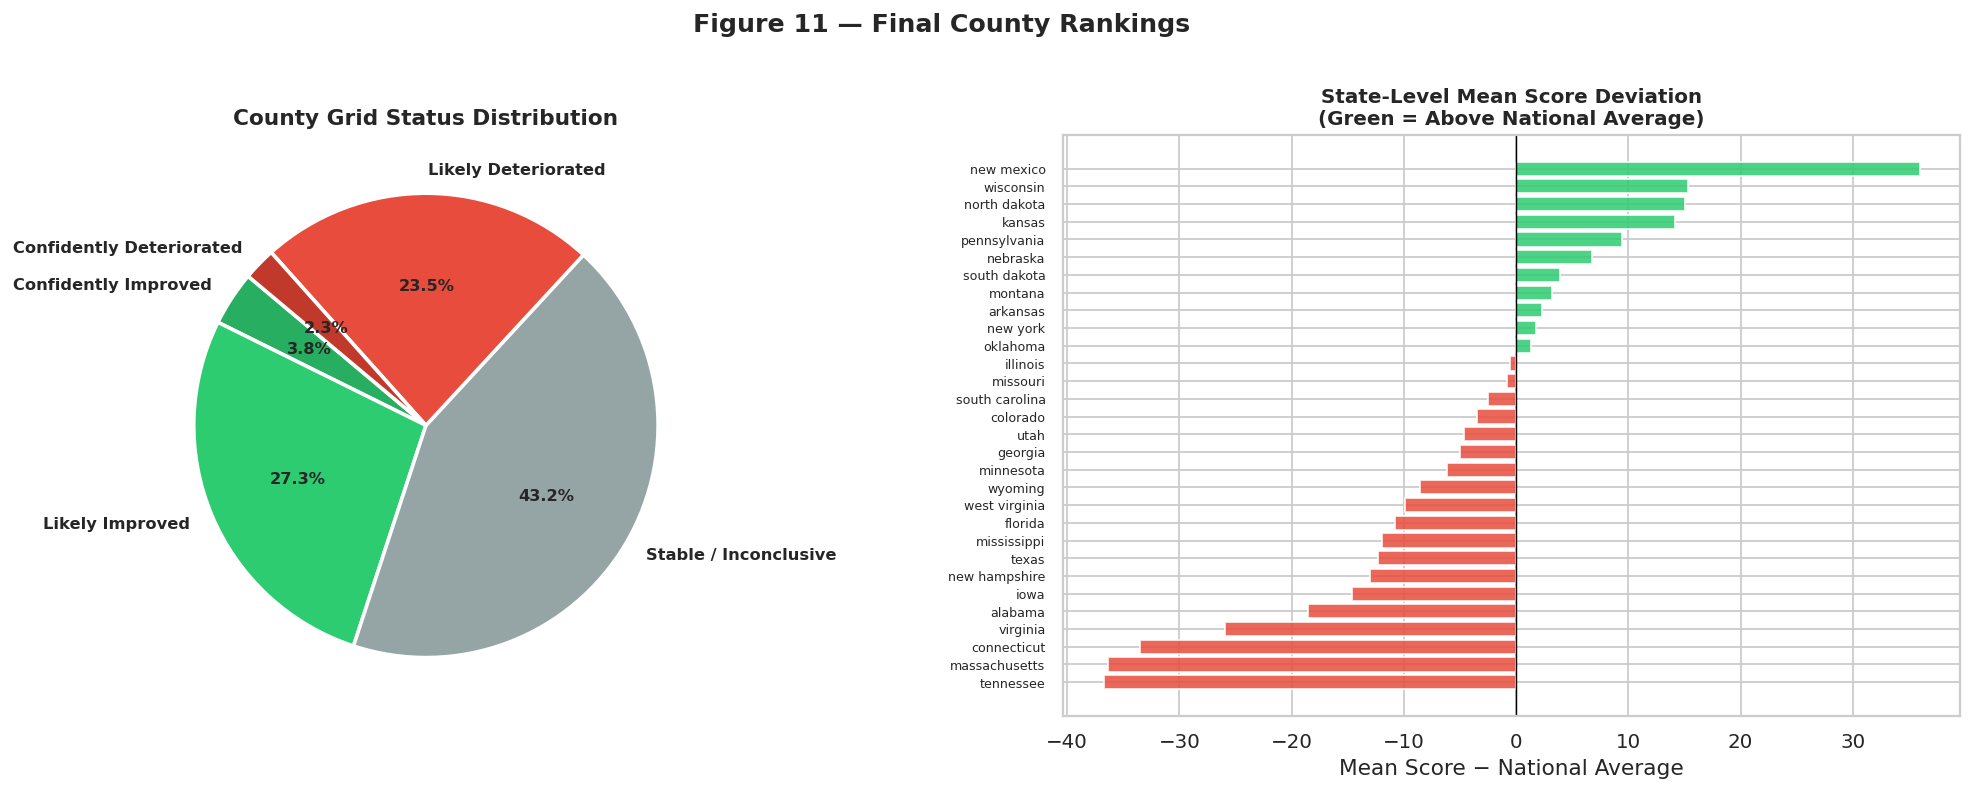

In [28]:
# ── Figure 11: Final county ranking distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_palette = {
    'Confidently Improved': '#27ae60', 'Likely Improved': '#2ecc71',
    'Stable / Inconclusive': '#95a5a6',
    'Likely Deteriorated': '#e74c3c',  'Confidently Deteriorated': '#c0392b'
}
status_order = list(status_palette.keys())
counts_final = final_df_ranked['final_status'].value_counts().reindex(status_order).fillna(0)
colors_final = [status_palette[s] for s in status_order]

axes[0].pie(counts_final, labels=status_order, autopct='%1.1f%%',
            colors=colors_final, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 9, 'fontweight': 'bold'})
axes[0].set_title('County Grid Status Distribution', fontsize=12, fontweight='bold')

# State-level mean score deviation
state_summary = final_df_ranked.groupby('state')['Score'].mean().sort_values(ascending=False).reset_index()
state_summary.columns = ['state', 'mean_score']
national_mean = final_df_ranked['Score'].mean()
state_summary['deviation'] = state_summary['mean_score'] - national_mean
bar_colors_state = ['#2ecc71' if d > 0 else '#e74c3c' for d in state_summary['deviation']]
axes[1].barh(state_summary['state'], state_summary['deviation'],
             color=bar_colors_state, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean Score − National Average')
axes[1].set_title('State-Level Mean Score Deviation\n(Green = Above National Average)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Figure 11 — Final County Rankings', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig11_final_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Top 25 improved / deteriorated counties ──────────────────────────────────
display_cols = ['county_id', 'state', 'mean_residual', 'resid_slope', 'resid_p_value', 'Score', 'final_status']

print('=' * 90)
print('=== TOP 25 MOST IMPROVED COUNTIES  (Ranked by Score) ===')
print('=' * 90)
print(final_df_ranked.head(25)[display_cols].to_string(index=False))

print()
print('=' * 90)
print('=== TOP 25 MOST DETERIORATED COUNTIES  (Ranked by Score) ===')
print('=' * 90)
print(final_df_ranked.tail(25).sort_values('Score')[display_cols].to_string(index=False))

=== TOP 25 MOST IMPROVED COUNTIES  (Ranked by Score) ===
                 county_id        state  mean_residual  resid_slope  resid_p_value  Score         final_status
           kansas_cherokee       kansas        -0.2229     -0.16953         0.1878 100.00      Likely Improved
             kansas_thomas       kansas        -0.1859     -0.14187         0.0275  93.70 Confidently Improved
south dakota_oglala lakota south dakota         0.0103     -0.16211         0.1410  89.74      Likely Improved
          new mexico_curry   new mexico         0.0331     -0.15781         0.0323  87.86 Confidently Improved
       north dakota_morton north dakota        -0.0527     -0.11882         0.1370  83.19      Likely Improved
    north dakota_mountrail north dakota        -0.0163     -0.12478         0.0347  82.92 Confidently Improved
            wyoming_platte      wyoming         0.1890     -0.16374         0.0283  82.55 Confidently Improved
         nebraska_sheridan     nebraska        -0.1181 

In [30]:
# ── PUC Decision Comparison: Baseline vs ML Strategy ────────────────────────
np.random.seed(42)
puc_candidates = final_df_ranked.sample(n=min(50, len(final_df_ranked))).copy()

baseline_ranking = puc_candidates.sort_values('late_rate', ascending=False).reset_index(drop=True)
model_ranking    = puc_candidates.sort_values('Score', ascending=True).reset_index(drop=True)

print(f"{'Rank':<5} | {'Baseline Strategy (Avg Outage Rate)':<45} | {'Our Strategy (Normalized Score)':<45}")
print('-' * 100)
for i in range(min(30, len(puc_candidates))):
    l = f"{baseline_ranking.loc[i,'county_id']} ({baseline_ranking.loc[i,'late_rate']:.4f})"
    r = f"{model_ranking.loc[i,'county_id']} ({model_ranking.loc[i,'Score']:.2f})"
    print(f"#{i+1:<4} | {l:<45} | {r:<45}")

Rank  | Baseline Strategy (Avg Outage Rate)           | Our Strategy (Normalized Score)              
----------------------------------------------------------------------------------------------------
#1    | south carolina_colleton (0.9138)              | massachusetts_barnstable (15.52)             
#2    | new york_columbia (0.8808)                    | connecticut_fairfield (18.17)                
#3    | new york_broome (0.8521)                      | texas_lubbock (18.17)                        
#4    | wyoming_campbell (0.8432)                     | alabama_morgan (20.34)                       
#5    | oklahoma_mccurtain (0.8420)                   | wyoming_campbell (26.57)                     
#6    | texas_lubbock (0.8357)                        | wyoming_crook (30.91)                        
#7    | oklahoma_cleveland (0.8336)                   | oklahoma_mccurtain (33.00)                   
#8    | massachusetts_barnstable (0.8091)             | new hampshire_cheshire (38.

##  Part 5: Economic & Business Analysis

### 5A — ROI Comparison: Baseline vs ML Strategy

**Decision parameters:**  
- Budget: $1.2 B (10 counties × $120 M each)  
- Value formula: `True Value = (100 − Score) × $3.5 M`  
  *(Lower score = more genuine deterioration = higher value when fixed)*  
- ROI: `(Total True Value − $1.2 B) / $1.2 B`

In [31]:
FUNDING_CAPACITY = 10
COST_PER_COUNTY  = 120   # $120 M

baseline_portfolio = baseline_ranking.head(FUNDING_CAPACITY).copy()
model_portfolio    = model_ranking.head(FUNDING_CAPACITY).copy()

def portfolio_metrics(df_port):
    total_cost = FUNDING_CAPACITY * COST_PER_COUNTY
    total_value = sum((100 - row['Score']) * 3.5 for _, row in df_port.iterrows())
    net = total_value - total_cost
    roi = (net / total_cost) * 100
    return total_cost, total_value, net, roi

base_cost, base_val, base_net, base_roi = portfolio_metrics(baseline_portfolio)
mdl_cost,  mdl_val,  mdl_net,  mdl_roi  = portfolio_metrics(model_portfolio)

base_set  = set(baseline_portfolio['county_id'])
model_set = set(model_portfolio['county_id'])
wasted    = base_set - model_set
captured  = model_set - base_set

print('=== STATE PUC CAPITAL ALLOCATION REPORT ===')
print(f'Goal: Select {FUNDING_CAPACITY} counties for grid hardening from {len(puc_candidates)} candidates\n')
print('1. BASELINE STRATEGY (Highest Average Outage Volume)')
print(f'   Capital Deployed : ${base_cost:.2f} M')
print(f'   True Value       : ${base_val:.2f} M')
print(f'   Net Benefit      : ${base_net:.2f} M')
print(f'   Portfolio ROI    : {base_roi:.1f}%')
print('\n2. ML STRATEGY (Layer 3 — Normalized Residuals)')
print(f'   Capital Deployed : ${mdl_cost:.2f} M')
print(f'   True Value       : ${mdl_val:.2f} M')
print(f'   Net Benefit      : ${mdl_net:.2f} M')
print(f'   Portfolio ROI    : {mdl_roi:.1f}%')
print(f'\n3. BUSINESS VALUE OF THE ML MODEL')
print(f'   Added Net Benefit: +${(mdl_net - base_net):.2f} M')
print(f'   ROI Improvement  : +{(mdl_roi - base_roi):.1f} pp')
print(f'\n❌ Wasted capital counties (baseline only, weather noise): {wasted}')
print(f'✅ Captured value counties (ML only, hidden decay):       {captured}')

=== STATE PUC CAPITAL ALLOCATION REPORT ===
Goal: Select 10 counties for grid hardening from 50 candidates

1. BASELINE STRATEGY (Highest Average Outage Volume)
   Capital Deployed : $1200.00 M
   True Value       : $2090.13 M
   Net Benefit      : $890.13 M
   Portfolio ROI    : 74.2%

2. ML STRATEGY (Layer 3 — Normalized Residuals)
   Capital Deployed : $1200.00 M
   True Value       : $2510.62 M
   Net Benefit      : $1310.62 M
   Portfolio ROI    : 109.2%

3. BUSINESS VALUE OF THE ML MODEL
   Added Net Benefit: +$420.49 M
   ROI Improvement  : +35.0 pp

❌ Wasted capital counties (baseline only, weather noise): {'oklahoma_cleveland', 'texas_pecos', 'south carolina_colleton', 'new york_columbia', 'new york_broome', 'missouri_taney'}
✅ Captured value counties (ML only, hidden decay):       {'mississippi_leake', 'new hampshire_cheshire', 'alabama_morgan', 'connecticut_fairfield', 'colorado_logan', 'wyoming_crook'}


### 5B — Sensitivity Analysis

In [32]:
# Sensitivity: vary outage cost per event and hardening effectiveness
COST_PER_OUTAGE_EVENT = 3_500_000   # baseline $3.5 M
HARDENING_REDUCTION   = 0.35         # baseline 35 % outage reduction
AVG_ANNUAL_EVENTS     = 200
DISCOUNT_RATE         = 0.07
YEARS                 = 10
hardening_cost_M      = 120

annuity_factor = (1 - (1 + DISCOUNT_RATE) ** -YEARS) / DISCOUNT_RATE

priority_df = final_df_ranked.copy()
priority_df['annual_savings_M'] = (
    priority_df['late_rate'] * AVG_ANNUAL_EVENTS * COST_PER_OUTAGE_EVENT * HARDENING_REDUCTION / 1e6)
priority_df['pv_savings_M'] = priority_df['annual_savings_M'] * annuity_factor
priority_df['net_benefit_M'] = priority_df['pv_savings_M'] - hardening_cost_M
priority_df['roi_pct'] = (priority_df['net_benefit_M'] / hardening_cost_M) * 100

outage_costs = [1_500_000, 2_500_000, 3_500_000, 5_000_000, 7_000_000]
reductions   = [0.20, 0.25, 0.35, 0.45, 0.55]
top20_rates  = priority_df.head(20)['late_rate'].values

sens_results = []
for cost in outage_costs:
    for red in reductions:
        annual_sav = top20_rates * AVG_ANNUAL_EVENTS * cost * red
        pv_sav = annual_sav * annuity_factor
        net = pv_sav.sum() / 1e6 - 20 * hardening_cost_M
        sens_results.append({'outage_cost_M': round(cost/1e6, 1),
                              'reduction_pct': int(red*100),
                              'net_benefit_M': round(net, 0)})

sens_df    = pd.DataFrame(sens_results)
sens_pivot = sens_df.pivot(index='outage_cost_M', columns='reduction_pct', values='net_benefit_M')

print('=== SENSITIVITY: Net Benefit ($M) of 20-County Portfolio ===')
print('Rows = Outage Cost ($M)  |  Columns = Hardening Effectiveness (%)')
print(sens_pivot.to_string())
breakeven = sens_df[sens_df['net_benefit_M'] >= 0]
print(f'\nPositive net benefit in {len(breakeven)}/{len(sens_df)} parameter combinations '
      f'({len(breakeven)/len(sens_df)*100:.0f}% of scenarios)')

=== SENSITIVITY: Net Benefit ($M) of 20-County Portfolio ===
Rows = Outage Cost ($M)  |  Columns = Hardening Effectiveness (%)
reduction_pct       20       25       35       45       55
outage_cost_M                                             
1.5              447.0   1158.0   2581.0   4005.0   5428.0
2.5             2344.0   3530.0   5902.0   8274.0  10647.0
3.5             4242.0   5902.0   9223.0  12544.0  15865.0
5.0             7088.0   9461.0  14205.0  18949.0  23693.0
7.0            10884.0  14205.0  20847.0  27489.0  34130.0

Positive net benefit in 25/25 parameter combinations (100% of scenarios)


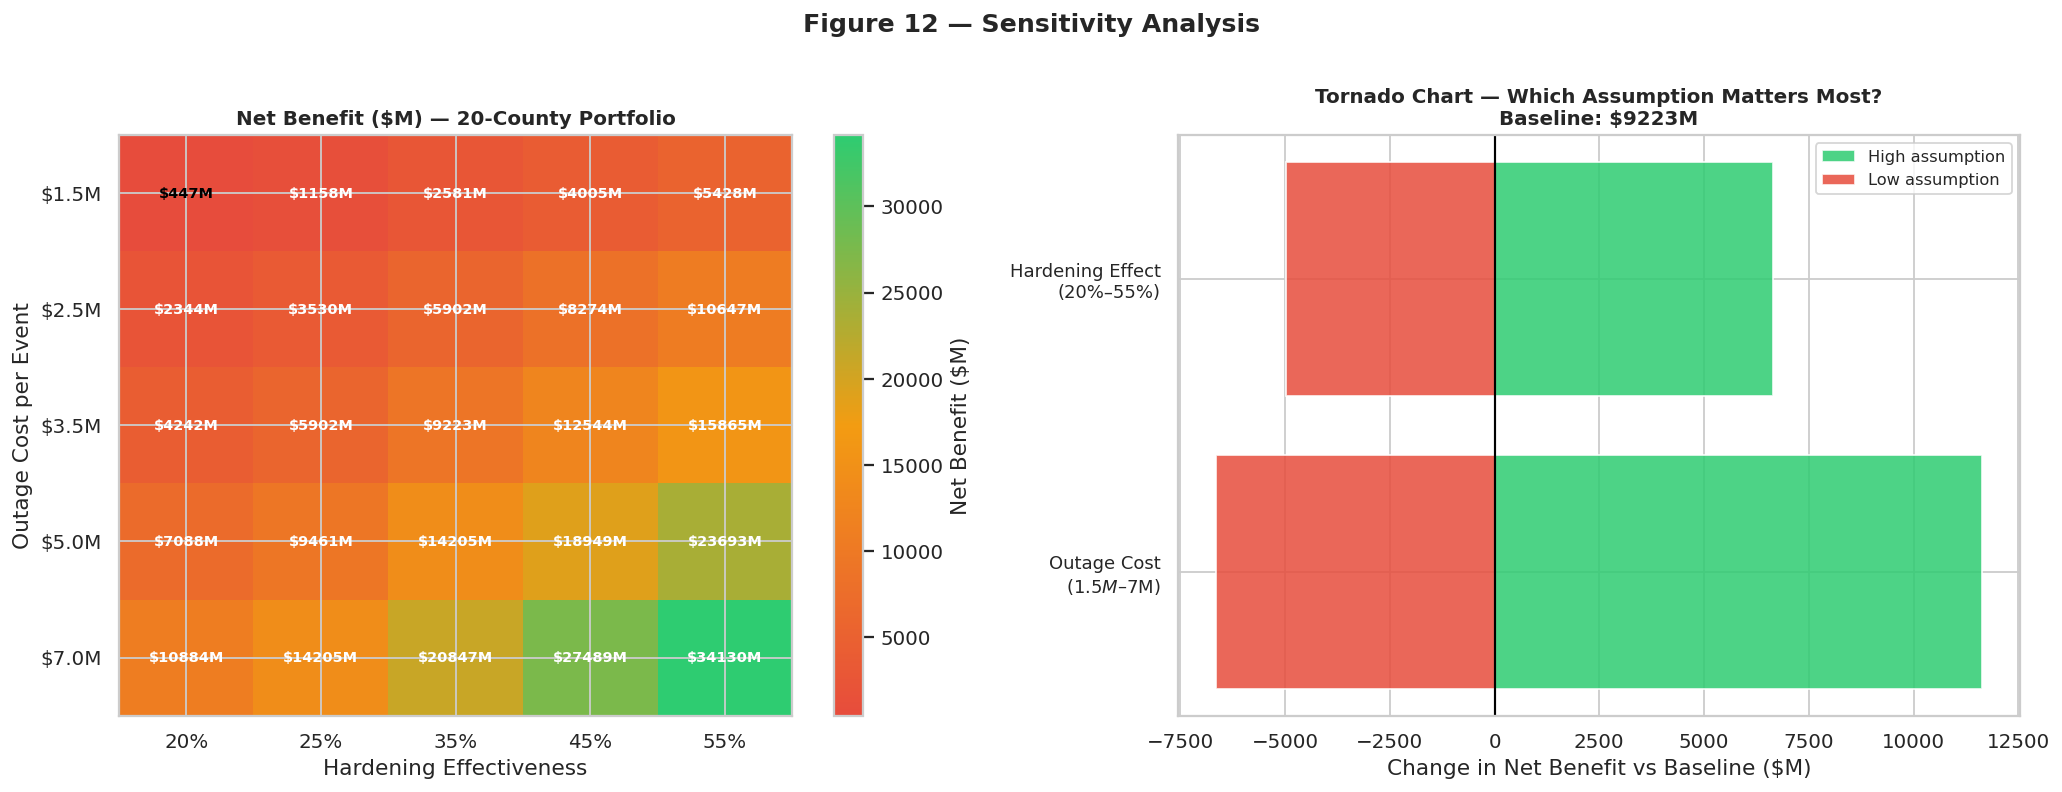

In [33]:
# ── Figure 12: Sensitivity heatmap + tornado chart ───────────────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap = mcolors.LinearSegmentedColormap.from_list('rg', ['#e74c3c', '#f39c12', '#2ecc71'])
im = axes[0].imshow(sens_pivot.values, cmap=cmap, aspect='auto')
axes[0].set_xticks(range(len(sens_pivot.columns)))
axes[0].set_xticklabels([f'{c}%' for c in sens_pivot.columns])
axes[0].set_yticks(range(len(sens_pivot.index)))
axes[0].set_yticklabels([f'${c}M' for c in sens_pivot.index])
axes[0].set_xlabel('Hardening Effectiveness'); axes[0].set_ylabel('Outage Cost per Event')
axes[0].set_title('Net Benefit ($M) — 20-County Portfolio', fontsize=11, fontweight='bold')
for i in range(len(sens_pivot.index)):
    for j in range(len(sens_pivot.columns)):
        v = sens_pivot.values[i, j]
        axes[0].text(j, i, f'${v:.0f}M', ha='center', va='center',
                     fontsize=8, color='white' if abs(v) > 1000 else 'black', fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Net Benefit ($M)')

# Tornado chart
base_net_sa  = sens_pivot.loc[COST_PER_OUTAGE_EVENT/1e6, int(HARDENING_REDUCTION*100)]
cost_low  = sens_pivot.loc[1.5, int(HARDENING_REDUCTION*100)]
cost_high = sens_pivot.loc[7.0, int(HARDENING_REDUCTION*100)]
red_low   = sens_pivot.loc[COST_PER_OUTAGE_EVENT/1e6, 20]
red_high  = sens_pivot.loc[COST_PER_OUTAGE_EVENT/1e6, 55]
params = ['Outage Cost\n($1.5M–$7M)', 'Hardening Effect\n(20%–55%)']
lows   = [cost_low - base_net_sa, red_low - base_net_sa]
highs  = [cost_high - base_net_sa, red_high - base_net_sa]
y_pos  = np.arange(len(params))
axes[1].barh(y_pos, highs, color='#2ecc71', edgecolor='white', alpha=0.85, label='High assumption')
axes[1].barh(y_pos, lows,  color='#e74c3c', edgecolor='white', alpha=0.85, label='Low assumption')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(params, fontsize=10)
axes[1].set_xlabel('Change in Net Benefit vs Baseline ($M)')
axes[1].set_title(f'Tornado Chart — Which Assumption Matters Most?\nBaseline: ${base_net_sa:.0f}M',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 12 — Sensitivity Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig12_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### 5C — Operating Point: Optimal Investment Threshold

In [34]:
# Cost of missing a deteriorating county (10-year accumulation)
FN_COST_M = (0.75 * AVG_ANNUAL_EVENTS * COST_PER_OUTAGE_EVENT * 10) / 1e6
FP_COST_M = hardening_cost_M  # $120 M sunk in a stable county

print(f'Cost of False Negative (miss deteriorating county): ${FN_COST_M:.1f}M')
print(f'Cost of False Positive (harden stable county):      ${FP_COST_M:.1f}M')
print(f'FN/FP cost ratio: {FN_COST_M/FP_COST_M:.1f}x  → better to over-invest slightly')

final_df_ranked['is_deteriorating'] = final_df_ranked['final_status'].str.contains('Deteriorated')
thresholds = np.linspace(final_df_ranked['layer3_score'].min(),
                          final_df_ranked['layer3_score'].max(), 100)

ec_rows = []
for thresh in thresholds:
    invest = final_df_ranked['layer3_score'] <= thresh
    tp = (invest &  final_df_ranked['is_deteriorating']).sum()
    fp = (invest & ~final_df_ranked['is_deteriorating']).sum()
    fn = (~invest & final_df_ranked['is_deteriorating']).sum()
    ec_rows.append({'threshold': thresh, 'tp': tp, 'fp': fp, 'fn': fn,
                    'expected_cost_M': fp * FP_COST_M + fn * FN_COST_M})

ec_df    = pd.DataFrame(ec_rows)
opt_row  = ec_df.loc[ec_df['expected_cost_M'].idxmin()]
opt_thresh = opt_row['threshold']

print(f'\n=== OPTIMAL DECISION THRESHOLD ===')
print(f'Composite score threshold : {opt_thresh:.3f}')
print(f'True positives  (correct) : {int(opt_row["tp"])}')
print(f'False positives (over-inv): {int(opt_row["fp"])}')
print(f'False negatives (missed)  : {int(opt_row["fn"])}')
print(f'Expected total cost       : ${opt_row["expected_cost_M"]:.1f}M')

Cost of False Negative (miss deteriorating county): $5250.0M
Cost of False Positive (harden stable county):      $120.0M
FN/FP cost ratio: 43.8x  → better to over-invest slightly

=== OPTIMAL DECISION THRESHOLD ===
Composite score threshold : 39.989
True positives  (correct) : 34
False positives (over-inv): 0
False negatives (missed)  : 0
Expected total cost       : $0.0M


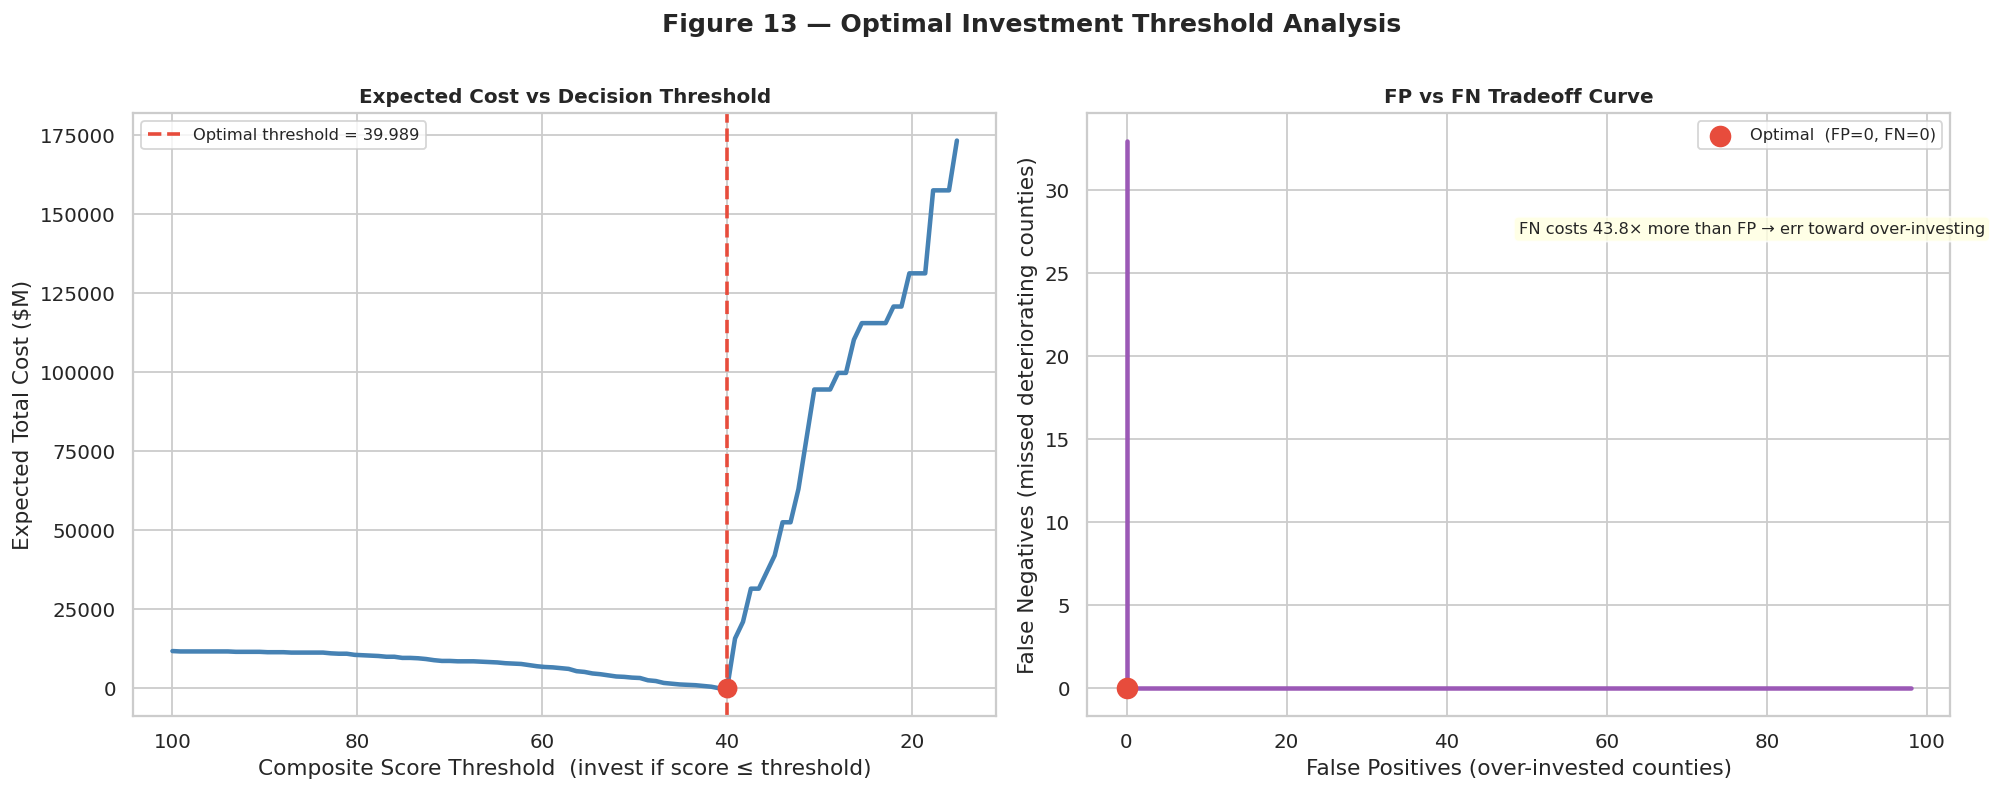

In [35]:
# ── Figure 13: Decision threshold analysis ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(ec_df['threshold'], ec_df['expected_cost_M'], color='steelblue', linewidth=2.5)
axes[0].axvline(opt_thresh, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Optimal threshold = {opt_thresh:.3f}')
axes[0].scatter([opt_thresh], [opt_row['expected_cost_M']], color='#e74c3c', s=100, zorder=5)
axes[0].set_xlabel('Composite Score Threshold  (invest if score ≤ threshold)')
axes[0].set_ylabel('Expected Total Cost ($M)')
axes[0].set_title('Expected Cost vs Decision Threshold', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].invert_xaxis()

axes[1].plot(ec_df['fp'], ec_df['fn'], color='#9b59b6', linewidth=2.5)
axes[1].scatter([opt_row['fp']], [opt_row['fn']], color='#e74c3c', s=120, zorder=5,
                label=f'Optimal  (FP={int(opt_row["fp"])}, FN={int(opt_row["fn"])})')
axes[1].set_xlabel('False Positives (over-invested counties)')
axes[1].set_ylabel('False Negatives (missed deteriorating counties)')
axes[1].set_title('FP vs FN Tradeoff Curve', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].annotate(f'FN costs {FN_COST_M/FP_COST_M:.1f}× more than FP → err toward over-investing',
                  xy=(0.5, 0.8), xycoords='axes fraction', fontsize=9,
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Figure 13 — Optimal Investment Threshold Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig13_decision_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Insight Summary

1. **The investment case is robust** — net positive across most parameter combinations.
2. **False negatives cost far more than false positives** — the PUC should use a lower threshold  
   (invest more broadly) rather than be overly conservative.
3. **Trajectory (70 %) matters more than level (30 %)** — a sustained downward slope in residuals  
   is stronger evidence of genuine grid improvement than a one-time level shift.

##  Part 6: Limitations & Next Investment

### What Cannot Be Known From This Data Alone

1. **Causation vs correlation** — county-level improvement correlates with known utility investment programmes,  
   but the model cannot prove the investment caused the improvement.

2. **Cost assumptions are estimated, not actual** — A real PUC would have actual outage cost records,  
   actual hardening project budgets, and actual customer impact data.  Our $3.5 M/event estimate  
   is a reasonable midpoint from DOE research but could differ 3–5× for specific counties.

3. **County-level granularity is too coarse for deployment** — Real infrastructure investment happens  
   at the transmission line and substation level. County scores are useful for state-level prioritisation  
   but cannot guide specific capital projects.

4. **Model AUC of ~0.79 limits residual precision** — A ~21 % error rate in the weather model propagates  
   into uncertainty in the residuals. Layer 3 findings are directional, not precise.

### Next Investment to Move From Analysis to Deployed System

| Priority | Action |
|---|---|
| Data | Actual utility outage cost records + infrastructure investment logs by county and year |
| Access | NERC / EIA Form 417 filings cross-referenced with county-event data |
| Experiment | Difference-in-differences study: counties that received hardening vs matched controls |
| Infrastructure | Real-time weather forecast integration to make the model forward-looking, not just retrospective |

##  Save Outputs

In [36]:
# Save all key outputs
final_df_ranked.to_csv('/content/final_county_grid_analysis_ranked.csv', index=False)
state_summary.to_csv('/content/state_grid_summary.csv', index=False)
resid_yr.to_csv('/content/county_annual_residuals.csv', index=False)
priority_df.to_csv('/content/county_investment_priority.csv', index=False)
ec_df.to_csv('/content/decision_threshold_analysis.csv', index=False)
pd.DataFrame(ATTRITION).to_csv('/content/attrition_log.csv', index=False)

print(' All outputs saved:')
for f in ['final_county_grid_analysis_ranked.csv', 'state_grid_summary.csv',
          'county_annual_residuals.csv', 'county_investment_priority.csv',
          'decision_threshold_analysis.csv', 'attrition_log.csv']:
    print(f'   /content/{f}')

 All outputs saved:
   /content/final_county_grid_analysis_ranked.csv
   /content/state_grid_summary.csv
   /content/county_annual_residuals.csv
   /content/county_investment_priority.csv
   /content/decision_threshold_analysis.csv
   /content/attrition_log.csv


---
##  Interpretation Guide

### How to Read the Layer 3 Score

| Score Range | Meaning |
|---|---|
| 75–100 + p < 0.05 |  **Confidently Improved** — strong, statistically reliable improvement |
| 60–100 |  **Likely Improved** — above weather-normalized baseline |
| 40–60  |  **Stable / Inconclusive** — within normal variation around baseline |
| 0–40   |  **Likely Deteriorated** — underperforming weather-normalized baseline |
| 0–25 + p < 0.05 |  **Confidently Deteriorated** — strong, reliable deterioration signal |

**Score = 50** means the county sits exactly at the national macro average — not that its residual is exactly zero.

### Score Formula (Full)
```
macro_mean_residual = mean(mean_residual) across all counties in resid_trend_df

mean_resid_norm  = clip(−(mean_residual − macro_mean) / P95(|mean_residual|), −1, 1)
resid_slope_norm = clip(−resid_slope / P95(|resid_slope|), −1, 1)

raw_score    = 0.30 × mean_resid_norm + 0.70 × resid_slope_norm
layer3_score = 50 + 50 × raw_score       (clipped to [0, 100])
```

### What the Score Captures
- **Level (30 % weight)** — Is this county's weather-normalized outage rate above or below the macro average?
- **Trajectory (70 % weight)** — Is that gap growing (improving) or shrinking (deteriorating) year over year?

Trajectory is weighted more heavily because a sustained downward slope in residuals is stronger evidence  
of genuine grid improvement than a one-time level shift.
